In [39]:
from pathlib import Path
import importlib.util
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import uproot
import dv_converter_utils as dvu

import h5py
from collections import Counter, defaultdict

# DisplacedVertex converter debug notebook

This notebook helps you:

- import and exercise the converter functions directly
- inspect one ROOT file and one event at a time
- validate event selection logic
- build muon/calo nodes and edges
- visualize graphs in $x$-$y$, $r$-$z$, $\eta$-$\phi$, and 3D
- spot missing branches, empty events, or geometry mismatches


## 1. Setup

Adjust the paths below before running.

In [ ]:
# ---- user config ----
SCRIPT_PATH = Path('DisplacedVertex_converter_cartesian.py')
INPUT_DIR = Path('hdd_data')
PATTERN = 'MuonBucketDump_H*/outputs/MuonBucketDump_group.det-muon.*root'

# viewer-like cuts
VERTEX_R_MAX_MM = 8000.0
VERTEX_Z_MAX_MM = 12000.0
CALO_R_MAX_MM = 4250.0
CALO_Z_MAX_MM = 6500.0
MIN_TOWER_ENERGY_MEV = 1000.0
MAX_TOWER_SEGMENT_DR = 0.4
SECTOR_MOD = 16
IS_MC = True
ALLOW_SINGLE_MODALITY = False

assert SCRIPT_PATH.exists(), f'Missing script: {SCRIPT_PATH.resolve()}'
files = sorted(glob.glob(str(INPUT_DIR / PATTERN)))
assert files, f'No ROOT files matched: {INPUT_DIR / PATTERN}'

print(f'Found {len(files)} ROOT files')
# take a random file for testing, from the list of matched files
random_file = np.random.choice(files)
ROOT_FILE = Path(random_file)
print('File:', ROOT_FILE)
# import the converter as a module
spec = importlib.util.spec_from_file_location('dvconv', str(SCRIPT_PATH))
dvconv = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dvconv)

# expose helper/selection functions from clean utility module
for _name in [
    '_open_tree_by_name', '_read_tree',
    '_event_passes_vertex_envelope', '_event_has_min_segments_and_truth',
    'build_edges_segment_tower_by_dr', 'edge_features',
    'REQUIRED_MUON_BRANCHES', 'REQUIRED_CALO_BRANCHES', 'REQUIRED_VERTEX_BRANCHES',
]:
    if not hasattr(dvconv, _name):
        setattr(dvconv, _name, getattr(dvu, _name))

print('Loaded module from', SCRIPT_PATH.resolve())

Found 81 ROOT files
File: hdd_data/MuonBucketDump_HAHM_ggFHZdZd_mumu_1200_0p001/outputs/MuonBucketDump_group.det-muon.49063825.EXT0._000005.RDO.root
Loaded module from /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLDisplacedVtx_clean/DisplacedVertex_converter_cartesian.py


## 2. Quick function sanity checks

In [2]:
# simple checks for geometry helpers from clean utility module
print('delta_phi(pi-0.1, -pi+0.1) =', dvu.delta_phi(np.pi - 0.1, -np.pi + 0.1))
print('first_intersection_with_envelope(eta=0, phi=0) =',
      dvu.first_intersection_with_envelope(0.0, 0.0, CALO_R_MAX_MM, CALO_Z_MAX_MM))

u = dvu.direction_from_eta_phi(eta=0.5, phi=1.0)
print('direction_from_eta_phi norm =', np.linalg.norm(u))

v = np.array([[3, 0, 4], [0, 0, 0]], dtype=np.float32)
print('safe_normalize =')
print(dvu._safe_normalize(v))

delta_phi(pi-0.1, -pi+0.1) = -0.1999999999999993
first_intersection_with_envelope(eta=0, phi=0) = (4250.0, 0.0, 2.6023746959452643e-13)
direction_from_eta_phi norm = 1.0
safe_normalize =
[[0.6 0.  0.8]
 [0.  0.  0. ]]


## 3. Inspect one ROOT file

In [3]:
f = uproot.open(ROOT_FILE)
print('Objects in file:')
for k in f.keys():
    print('  ', k)

Objects in file:
   CaloDump;1
   MuonBucketDump;1
   MuonVertexDump;1


In [4]:
for tree_name in ['MuonBucketDump', 'CaloDump', 'MuonVertexDump']:
    tree = dvconv._open_tree_by_name(ROOT_FILE, tree_name)
    print(f'\n[{tree_name}] num_entries =', tree.num_entries)
    keys = [k.split(';')[0] for k in tree.keys()]
    print('First 20 branches:')
    for k in keys[:20]:
        print('  ', k)


[MuonBucketDump] num_entries = 962011
First 20 branches:
   CommonEventHash[2]/l
   Layer
   adc
   bucket_chamberIndex
   bucket_hasTruth
   bucket_layers
   bucket_max
   bucket_min
   bucket_ml_score_class0
   bucket_ml_score_class1
   bucket_ml_score_class2
   bucket_positionX
   bucket_positionY
   bucket_positionZ
   bucket_sector
   bucket_segments
   bucket_side
   bucket_spacePoints
   covX
   covY

[CaloDump] num_entries = 2000
First 20 branches:
   CommonEventHash[2]/l
   cell_energy_mev
   cell_eta
   cell_id_stationEta
   cell_id_stationIndex
   cell_id_stationPhi
   cell_isTile
   cell_phi
   cell_positionX
   cell_positionY
   cell_positionZ
   cell_sampling
   cell_subCalo
   tower_directionX
   tower_directionY
   tower_directionZ
   tower_energy_mev
   tower_et_mev
   tower_eta
   tower_nCells

[MuonVertexDump] num_entries = 2000
First 20 branches:
   CommonEventHash[2]/l
   truthMuon_pt
   truthMuon_eta
   truthMuon_phi
   truthMuon_e
   truthMuon_q
   truthMuonVert

## 4. Read the three trees and build event maps

In [5]:
mu_td, mu_ev_to_idx, mu_keys = dvconv._read_tree(ROOT_FILE, 'MuonBucketDump', dvconv.REQUIRED_MUON_BRANCHES)
ca_td, ca_ev_to_idx, ca_keys = dvconv._read_tree(ROOT_FILE, 'CaloDump', dvconv.REQUIRED_CALO_BRANCHES)
vx_td, vx_ev_to_idx, vx_keys = dvconv._read_tree(ROOT_FILE, 'MuonVertexDump', dvconv.REQUIRED_VERTEX_BRANCHES)

print('Muon events   :', len(mu_keys))
print('Calo events   :', len(ca_keys))
print('Vertex events :', len(vx_keys))

Muon events   : 2000
Calo events   : 2000
Vertex events : 2000


## Check cuts

In [6]:
# unit diagnostic: inspect raw ranges in loaded trees
import numpy as np

def _concat_numeric_from_object_array(obj_arr):
    vals = []
    for x in obj_arr:
        a = np.asarray(x).ravel()
        if a.size:
            vals.append(a.astype(np.float64))
    if not vals:
        return np.array([], dtype=np.float64)
    return np.concatenate(vals)

vx_x = _concat_numeric_from_object_array(vx_td['truthMuonVertexPositionX'])
vx_y = _concat_numeric_from_object_array(vx_td['truthMuonVertexPositionY'])
vx_z = _concat_numeric_from_object_array(vx_td['truthMuonVertexPositionZ'])
vx_r = np.hypot(vx_x, vx_y)

mu_x = _concat_numeric_from_object_array(mu_td['segmentPositionX'])
mu_y = _concat_numeric_from_object_array(mu_td['segmentPositionY'])
mu_z = _concat_numeric_from_object_array(mu_td['segmentPositionZ'])
mu_r = np.hypot(mu_x, mu_y)

def _summary(name, arr):
    if arr.size == 0:
        print(f'{name}: empty')
        return
    q = np.percentile(arr, [0, 1, 50, 99, 100])
    print(f'{name}: n={arr.size:,} min={q[0]:.3f} p1={q[1]:.3f} p50={q[2]:.3f} p99={q[3]:.3f} max={q[4]:.3f}')

print('Inspecting file:', ROOT_FILE)

print('--- Raw coordinate ranges from ROOT ---')
_summary('vertex_x', vx_x)
_summary('vertex_y', vx_y)
_summary('vertex_z', vx_z)
_summary('vertex_r', vx_r)
_summary('segment_x', mu_x)
_summary('segment_y', mu_y)
_summary('segment_z', mu_z)
_summary('segment_r', mu_r)

# compare envelope interpretation
r_cut_mm = VERTEX_R_MAX_MM
z_cut_mm = VERTEX_Z_MAX_MM
pass_mm = (vx_r <= r_cut_mm) & (np.abs(vx_z) <= z_cut_mm)

print('\n--- Fraction of individual truth vertices passing envelope ---')
print(f'Using cuts as mm (r<= {r_cut_mm}, |z|<= {z_cut_mm}): {pass_mm.mean():.6f}')

# also test clean util extra lower-r cut currently used
pass_mm_with_min = (vx_r > 30.0) & pass_mm
print(f'Using clean util extra min r > 30 mm + envelope: {pass_mm_with_min.mean():.6f}')

Inspecting file: hdd_data/MuonBucketDump_HAHM_ggFHZdZd_mumu_500_0p001/outputs/MuonBucketDump_group.det-muon.49063837.EXT0._000001.RDO.root
--- Raw coordinate ranges from ROOT ---
vertex_x: n=4,000 min=-1366.606 p1=-404.155 p50=-0.187 p99=437.286 max=2695.743
vertex_y: n=4,000 min=-1218.541 p1=-463.041 p50=-0.145 p99=414.621 max=1675.637
vertex_z: n=4,000 min=-10028.603 p1=-2653.394 p50=-2.349 p99=2340.018 max=20816.439
vertex_r: n=4,000 min=0.013 p1=0.774 p50=71.724 p99=752.412 max=3174.080
segment_x: n=304,630 min=-12177.870 p1=-9708.355 p50=-0.000 p99=9708.355 max=12129.388
segment_y: n=304,630 min=-12166.205 p1=-11262.942 p50=0.000 p99=9708.355 max=12422.331
segment_z: n=304,630 min=-21840.539 p1=-21840.539 p50=663.944 p99=21840.539 max=21840.539
segment_r: n=304,630 min=636.130 p1=1852.553 p50=5044.485 p99=11588.113 max=13108.830

--- Fraction of individual truth vertices passing envelope ---
Using cuts as mm (r<= 8000.0, |z|<= 12000.0): 0.999250
Using clean util extra min r > 30 m

## 5. Reproduce event filtering and find candidate events

In [7]:
mu_set = set(mu_keys)
ca_set = set(ca_keys)

if ALLOW_SINGLE_MODALITY:
    event_keys = [k for k in vx_keys if (k in mu_set) or (k in ca_set)]
else:
    event_keys = [k for k in vx_keys if (k in mu_set) and (k in ca_set)]

stats = {
    'candidate_from_keys': 0,
    'pass_vertex': 0,
    'pass_min_segments_truth': 0,
    'pass_target': 0,
    'pass_mu_nodes': 0,
    'pass_calo_nodes': 0,
    'pass_edges': 0,
}

passing_events = []

for evh in event_keys:
    stats['candidate_from_keys'] += 1
    vx_idxs = np.asarray(vx_ev_to_idx[evh], dtype=np.int64)

    if not dvconv._event_passes_vertex_envelope(vx_td, vx_idxs, VERTEX_R_MAX_MM, VERTEX_Z_MAX_MM):
        continue
    stats['pass_vertex'] += 1

    if evh not in mu_ev_to_idx:
        continue
    mu_idxs = np.asarray(mu_ev_to_idx[evh], dtype=np.int64)

    if not dvconv._event_has_min_segments_and_truth(mu_td, mu_idxs, min_segments=2, require_truth=IS_MC, min_truth=2):
        continue
    stats['pass_min_segments_truth'] += 1

    y_vertex = dvconv._build_vertex_target(vx_td, vx_idxs)
    if y_vertex is None:
        continue
    stats['pass_target'] += 1

    mu_nodes = dvconv._build_muon_nodes(mu_td, mu_idxs)
    if mu_nodes is None:
        continue
    stats['pass_mu_nodes'] += 1

    ca_nodes = None
    if evh in ca_ev_to_idx:
        ca_nodes = dvconv._build_calo_nodes(
            ca_td,
            np.asarray(ca_ev_to_idx[evh], dtype=np.int64),
            sector_mod=SECTOR_MOD,
            min_tower_energy_mev=MIN_TOWER_ENERGY_MEV,
            max_tower_segment_dr=MAX_TOWER_SEGMENT_DR,
            calo_r_max_mm=CALO_R_MAX_MM,
            calo_z_max_mm=CALO_Z_MAX_MM,
            seg_eta_list=mu_nodes['eta'],
            seg_phi_list=mu_nodes['phi'],
        )

    if ca_nodes is None and not ALLOW_SINGLE_MODALITY:
        continue
    if ca_nodes is not None:
        stats['pass_calo_nodes'] += 1

    pieces = [mu_nodes['x']]
    phi_pieces = [mu_nodes['phi']]
    eta_pieces = [mu_nodes['eta']]
    energy_like_pieces = [mu_nodes['energy_like']]
    dir_pieces = [mu_nodes['dir_u']]
    sector_pieces = [mu_nodes['sector']]
    type_pieces = [mu_nodes['node_type']]

    if ca_nodes is not None:
        pieces.append(ca_nodes['x'])
        phi_pieces.append(ca_nodes['phi'])
        eta_pieces.append(ca_nodes['eta'])
        energy_like_pieces.append(ca_nodes['energy_like'])
        dir_pieces.append(ca_nodes['dir_u'])
        sector_pieces.append(ca_nodes['sector'])
        type_pieces.append(ca_nodes['node_type'])

    x = np.concatenate(pieces, axis=0).astype(np.float32)
    phi = np.concatenate(phi_pieces, axis=0).astype(np.float32)
    eta = np.concatenate(eta_pieces, axis=0).astype(np.float32)
    energy_like = np.concatenate(energy_like_pieces, axis=0).astype(np.float32)
    dir_u = np.concatenate(dir_pieces, axis=0).astype(np.float32)
    sector = np.concatenate(sector_pieces, axis=0).astype(np.int64)
    node_type = np.concatenate(type_pieces, axis=0).astype(np.int64)

    edge_index = dvconv.build_edges_segment_tower_by_dr(
        phi=phi,
        eta=eta,
        node_type=node_type,
        max_tower_segment_dr=MAX_TOWER_SEGMENT_DR,
    )

    if edge_index.shape[1] == 0:
        continue
    stats['pass_edges'] += 1

    edge_attr = dvconv.edge_features(
        energy_like=energy_like,
        phi=phi,
        eta=eta,
        dir_u=dir_u,
        sector=sector,
        node_type=node_type,
        edge_index=edge_index,
    )

    passing_events.append({
        'event_hash': evh,
        'y_vertex': y_vertex,
        'mu_nodes': mu_nodes,
        'ca_nodes': ca_nodes,
        'x': x,
        'phi': phi,
        'eta': eta,
        'energy_like': energy_like,
        'dir_u': dir_u,
        'sector': sector,
        'node_type': node_type,
        'edge_index': edge_index,
        'edge_attr': edge_attr,
    })

stats

{'candidate_from_keys': 2000,
 'pass_vertex': 1062,
 'pass_min_segments_truth': 1062,
 'pass_target': 1062,
 'pass_mu_nodes': 1062,
 'pass_calo_nodes': 1062,
 'pass_edges': 1062}

In [8]:
print(f'Passing events found: {len(passing_events)}')
if passing_events:
    print('First passing event hash:', passing_events[0]['event_hash'])

Passing events found: 1062
First passing event hash: (1, 2343389991622648)


## 6. Pick one event and inspect tensors

In [9]:
EVENT_IDX = 0
ev = passing_events[EVENT_IDX]

print('event_hash   =', ev['event_hash'])
print('y_vertex [m] =', ev['y_vertex'])
print('x shape      =', ev['x'].shape)
print('edge_index   =', ev['edge_index'].shape)
print('edge_attr    =', ev['edge_attr'].shape)
print('n mu nodes   =', int(np.sum(ev['node_type'] == 0)))
print('n ca nodes   =', int(np.sum(ev['node_type'] == 1)))

print('\nFirst 5 nodes:')
print(ev['x'][:5])

print('\nFirst 5 edges:')
print(ev['edge_index'][:, :5])
print(ev['edge_attr'][:5])

event_hash   = (1, 2343389991622648)
y_vertex [m] = [-0.13183922  0.00143147 -0.05143714]
x shape      = (995, 8)
edge_index   = (2, 4816)
edge_attr    = (4816, 5)
n mu nodes   = 165
n ca nodes   = 830

First 5 nodes:
[[  6.668359    -2.7621248   21.84054      0.3739824   -0.15490858
    0.9144072    0.           2.        ]
 [  8.465314    -3.5064478   21.84054      0.51836264  -0.21471281
    0.8277673    0.           5.        ]
 [  1.2714401   -3.069528    21.84054      0.08564996  -0.20677729
    0.97463185   0.           4.        ]
 [  2.6174057    1.0841651   21.84054      0.1769694    0.07330313
    0.9814828    0.           4.        ]
 [  1.9594852   -4.7306156  -21.84054      0.12933035  -0.3122311
   -0.94116175   0.           4.        ]]

First 5 edges:
[[  0 738   0 751   0]
 [738   0 751   0 752]]
[[ 1.7899402e+03  4.9087286e-02 -3.7661636e-01  9.9881297e-01
   0.0000000e+00]
 [-1.7899402e+03 -4.9087286e-02  3.7661636e-01  9.9881297e-01
   0.0000000e+00]
 [ 1.1100087e+

## 7. Helper plotting functions

In [10]:
def split_modalities(ev):
    node_type = ev['node_type']
    mu = np.where(node_type == 0)[0]
    ca = np.where(node_type == 1)[0]
    return mu, ca


def plot_eta_phi(ev, draw_edges=True, max_edges=2000):
    mu, ca = split_modalities(ev)
    phi = ev['phi']
    eta = ev['eta']
    edge_index = ev['edge_index']

    plt.figure(figsize=(8, 6))
    plt.scatter(phi[mu], eta[mu], s=18, label='muon segments')
    plt.scatter(phi[ca], eta[ca], s=24, marker='s', label='calo towers')

    if draw_edges:
        n_draw = min(edge_index.shape[1], max_edges)
        for k in range(n_draw):
            i, j = edge_index[:, k]
            plt.plot([phi[i], phi[j]], [eta[i], eta[j]], alpha=0.15)

    plt.xlabel('phi')
    plt.ylabel('eta')
    plt.title('Graph in eta-phi')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_xy(ev, draw_dirs=True, scale=0.5):
    mu, ca = split_modalities(ev)
    pos = ev['x'][:, :3]
    dirs = ev['x'][:, 3:6]

    plt.figure(figsize=(7, 7))
    plt.scatter(pos[mu, 0], pos[mu, 1], s=20, label='muon segments')
    plt.scatter(pos[ca, 0], pos[ca, 1], s=25, marker='s', label='calo towers')

    if draw_dirs:
        plt.quiver(pos[:, 0], pos[:, 1], dirs[:, 0], dirs[:, 1], angles='xy', scale_units='xy', scale=1/scale, width=0.003)

    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    plt.title('Node positions in x-y')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_rz(ev):
    mu, ca = split_modalities(ev)
    pos = ev['x'][:, :3]
    r = np.hypot(pos[:, 0], pos[:, 1])

    plt.figure(figsize=(8, 6))
    plt.scatter(pos[mu, 2], r[mu], s=20, label='muon segments')
    plt.scatter(pos[ca, 2], r[ca], s=25, marker='s', label='calo towers')
    plt.xlabel('z [m]')
    plt.ylabel('r [m]')
    plt.title('Node positions in r-z')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_3d(ev, max_edges=600):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    mu, ca = split_modalities(ev)
    pos = ev['x'][:, :3]
    edge_index = ev['edge_index']

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(pos[mu, 0], pos[mu, 1], pos[mu, 2], s=18, label='muon segments')
    ax.scatter(pos[ca, 0], pos[ca, 1], pos[ca, 2], s=22, marker='s', label='calo towers')

    n_draw = min(edge_index.shape[1], max_edges)
    for k in range(n_draw):
        i, j = edge_index[:, k]
        ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]], [pos[i, 2], pos[j, 2]], alpha=0.12)

    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_zlabel('z [m]')
    ax.set_title('3D graph view')
    ax.legend()
    plt.show()


def plot_edge_attr_histograms(ev):
    ea = ev['edge_attr']
    names = ['d_energy_like', 'd_phi_wrapped', 'd_eta', 'cos_angle', 'same_sector']
    fig, axs = plt.subplots(1, len(names), figsize=(18, 3.5))
    for ax, name, arr in zip(axs, names, ea.T):
        ax.hist(arr, bins=40)
        ax.set_title(name)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Visualize the selected event

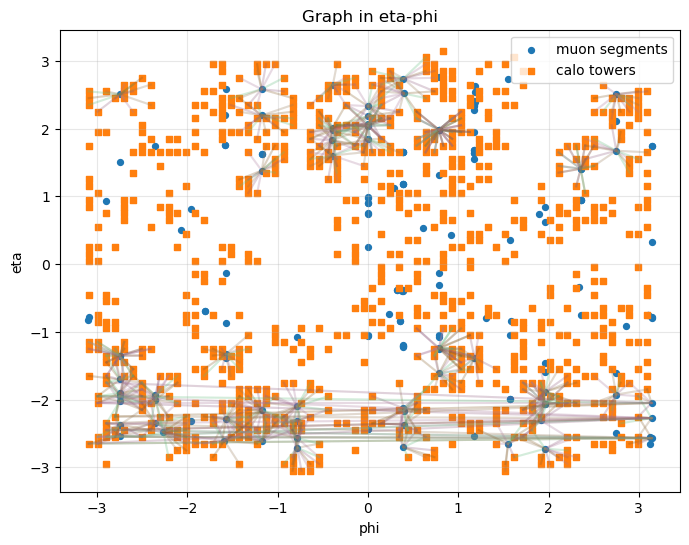

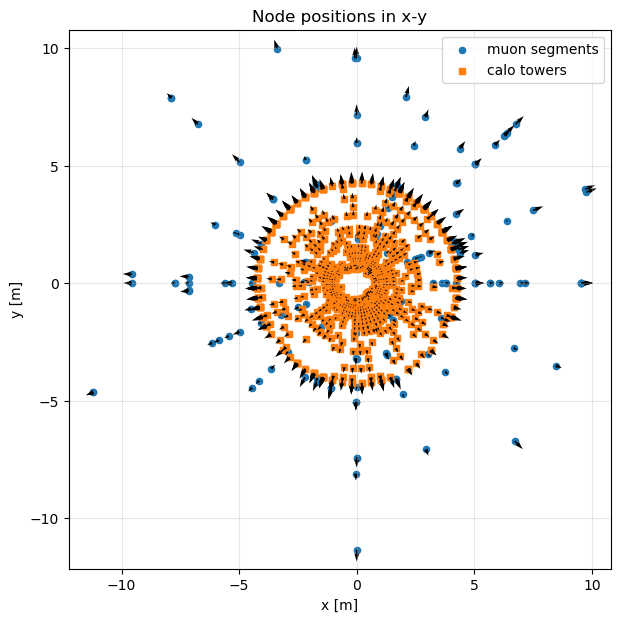

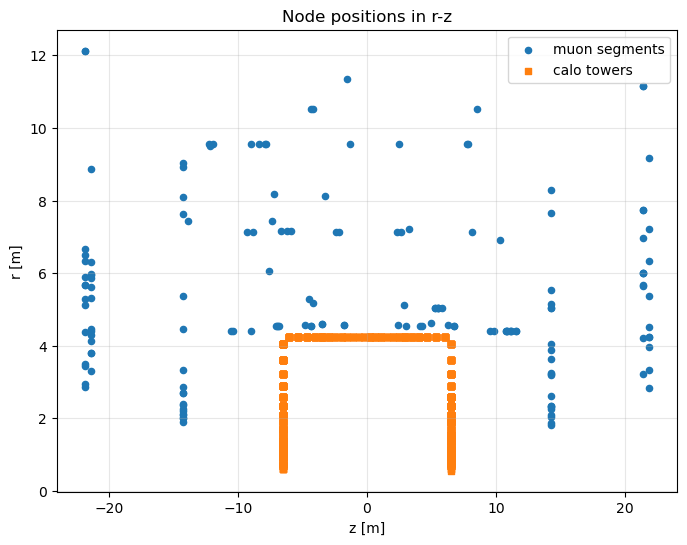

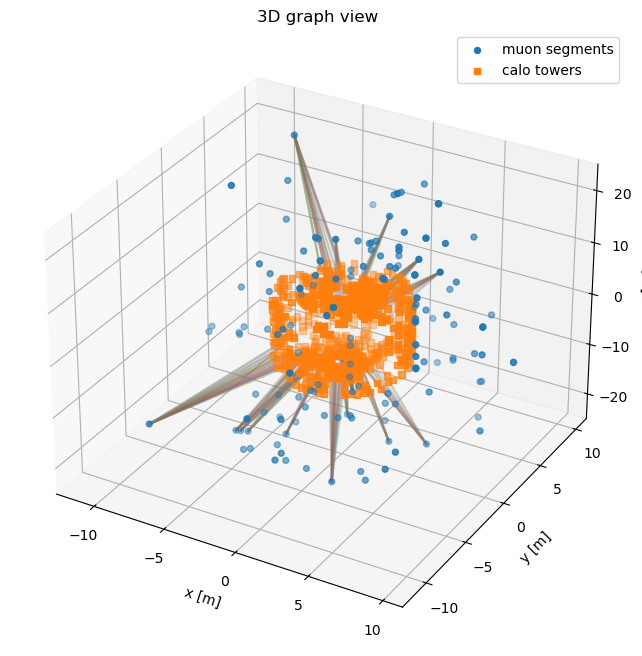

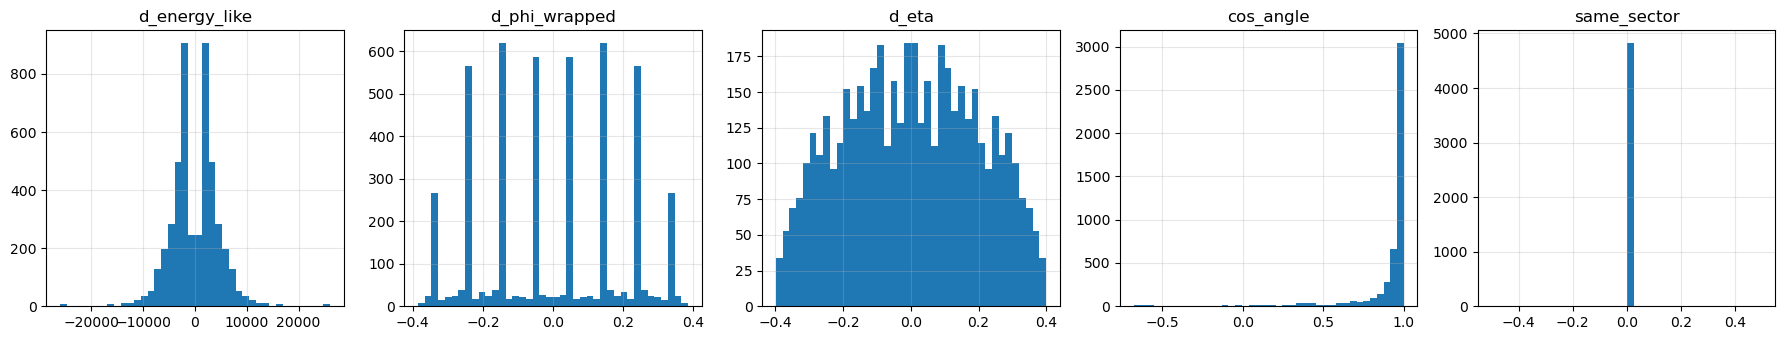

In [11]:
plot_eta_phi(ev)
plot_xy(ev)
plot_rz(ev)
plot_3d(ev)
plot_edge_attr_histograms(ev)

## 9. Debug helpers for missing events

In [12]:
def diagnose_event(evh):
    report = {'event_hash': evh}

    report['in_mu'] = evh in mu_ev_to_idx
    report['in_ca'] = evh in ca_ev_to_idx
    report['in_vx'] = evh in vx_ev_to_idx

    if report['in_vx']:
        vx_idxs = np.asarray(vx_ev_to_idx[evh], dtype=np.int64)
        report['pass_vertex'] = dvconv._event_passes_vertex_envelope(vx_td, vx_idxs, VERTEX_R_MAX_MM, VERTEX_Z_MAX_MM)
        report['y_vertex'] = dvconv._build_vertex_target(vx_td, vx_idxs)
    else:
        report['pass_vertex'] = False
        report['y_vertex'] = None

    if report['in_mu']:
        mu_idxs = np.asarray(mu_ev_to_idx[evh], dtype=np.int64)
        report['pass_segment_truth'] = dvconv._event_has_min_segments_and_truth(
            mu_td, mu_idxs, min_segments=2, require_truth=IS_MC, min_truth=2
        )
        mu_nodes = dvconv._build_muon_nodes(mu_td, mu_idxs)
        report['mu_nodes'] = None if mu_nodes is None else mu_nodes['x'].shape[0]
    else:
        report['pass_segment_truth'] = False
        report['mu_nodes'] = None
        mu_nodes = None

    if report['in_ca'] and mu_nodes is not None:
        ca_nodes = dvconv._build_calo_nodes(
            ca_td,
            np.asarray(ca_ev_to_idx[evh], dtype=np.int64),
            sector_mod=SECTOR_MOD,
            min_tower_energy_mev=MIN_TOWER_ENERGY_MEV,
            max_tower_segment_dr=MAX_TOWER_SEGMENT_DR,
            calo_r_max_mm=CALO_R_MAX_MM,
            calo_z_max_mm=CALO_Z_MAX_MM,
            seg_eta_list=mu_nodes['eta'],
            seg_phi_list=mu_nodes['phi'],
        )
        report['ca_nodes'] = None if ca_nodes is None else ca_nodes['x'].shape[0]
    else:
        report['ca_nodes'] = None

    return report

In [13]:
# Example:
# diagnose_event(vx_keys[0])

## 10. Optional: browse several events quickly

In [14]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    def show_event(idx=0):
        clear_output(wait=True)
        display(slider)
        ev = passing_events[idx]
        print('event_hash:', ev['event_hash'])
        print('n_nodes:', ev['x'].shape[0], 'n_edges:', ev['edge_index'].shape[1])
        plot_eta_phi(ev, draw_edges=True, max_edges=500)
        plot_xy(ev, draw_dirs=False)

    slider = widgets.IntSlider(value=0, min=0, max=max(0, len(passing_events) - 1), step=1, description='event')
    widgets.interactive_output(show_event, {'idx': slider})
    display(slider)
except Exception as e:
    print('ipywidgets not available:', e)

IntSlider(value=0, description='event', max=1061)

event_hash: (1, 2343389991622648)
n_nodes: 995 n_edges: 4816


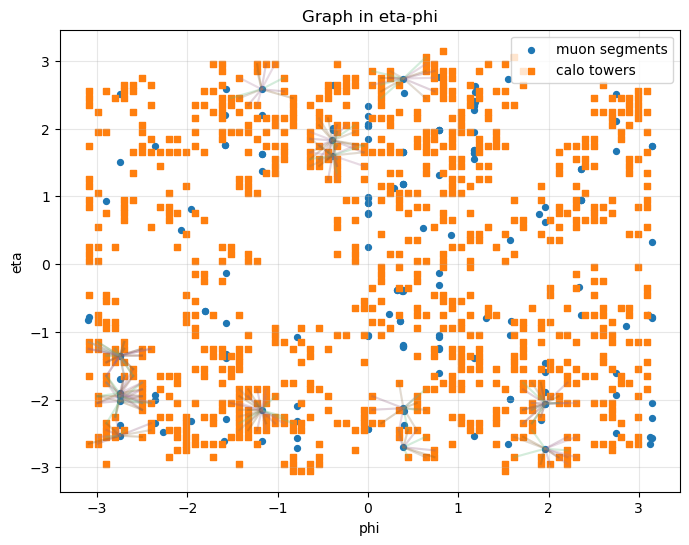

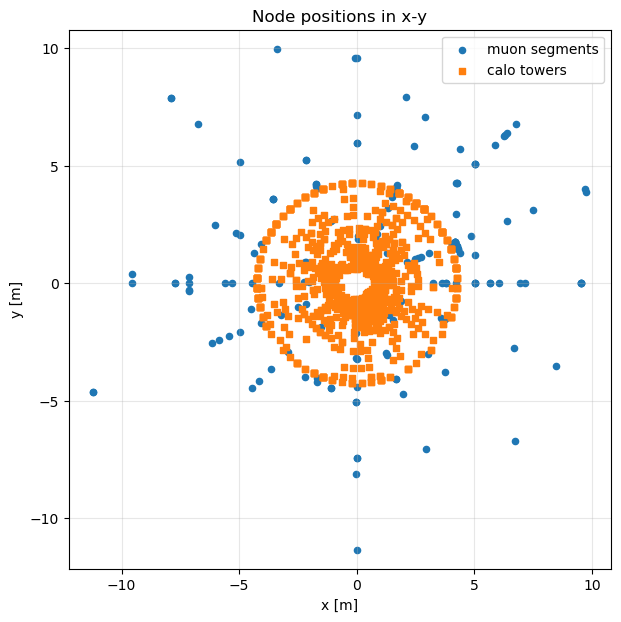

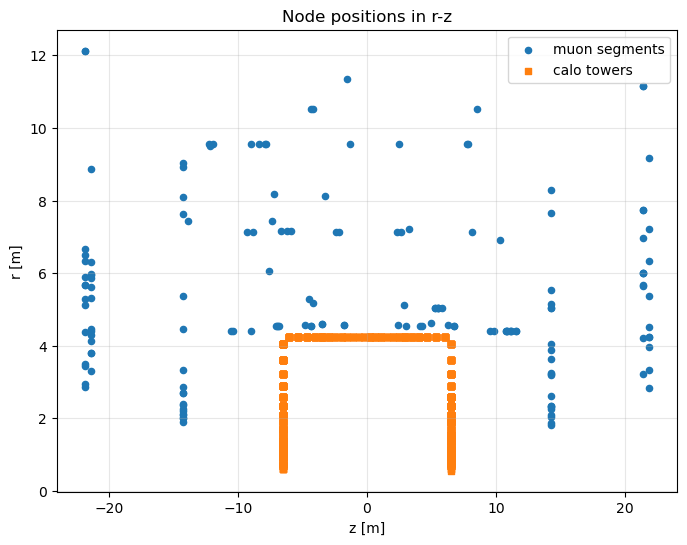

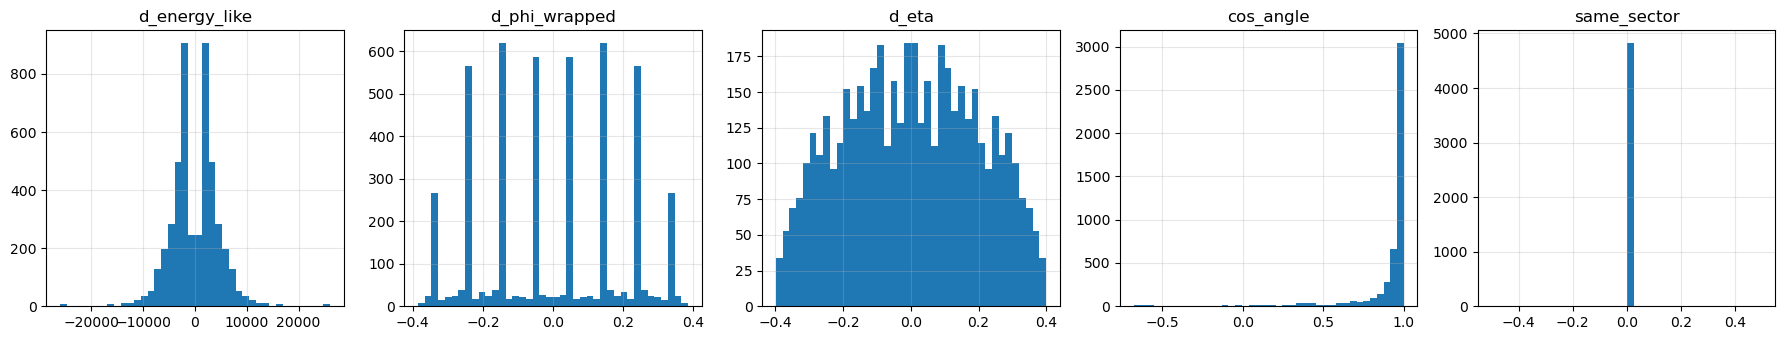

In [15]:
# simple manual browser without ipywidgets

EVENT_IDX = 0  # change this by hand

ev = passing_events[EVENT_IDX]
print('event_hash:', ev['event_hash'])
print('n_nodes:', ev['x'].shape[0], 'n_edges:', ev['edge_index'].shape[1])

plot_eta_phi(ev, draw_edges=True, max_edges=500)
plot_xy(ev, draw_dirs=False)
plot_rz(ev)
plot_edge_attr_histograms(ev)

In [16]:
def show_event(idx):
    ev = passing_events[idx]
    vx, vy, vz = ev['y_vertex']

    print('event index :', idx)
    print('event_hash  :', ev['event_hash'])
    print('vertex [m]  : x = %.4f  y = %.4f  z = %.4f' % (vx, vy, vz))

    print('n_nodes     :', ev['x'].shape[0])
    print('n_edges     :', ev['edge_index'].shape[1])
    print('n_mu_nodes  :', int(np.sum(ev['node_type'] == 0)))
    print('n_ca_nodes  :', int(np.sum(ev['node_type'] == 1)))

    # distance of nodes from vertex (useful debug)
    pos = ev['x'][:, :3]
    d = np.linalg.norm(pos - ev['y_vertex'], axis=1)
    print('node distance from vertex [m]:')
    print('  min = %.3f  mean = %.3f  max = %.3f' % (d.min(), d.mean(), d.max()))

    plot_eta_phi(ev, draw_edges=True, max_edges=500)
    plot_xy(ev, draw_dirs=False)
    plot_rz(ev)
    plot_edge_attr_histograms(ev)

event index : 0
event_hash  : (1, 2343389991622648)
vertex [m]  : x = -0.1318  y = 0.0014  z = -0.0514
n_nodes     : 995
n_edges     : 4816
n_mu_nodes  : 165
n_ca_nodes  : 830
node distance from vertex [m]:
  min = 4.123  mean = 7.840  max = 24.878


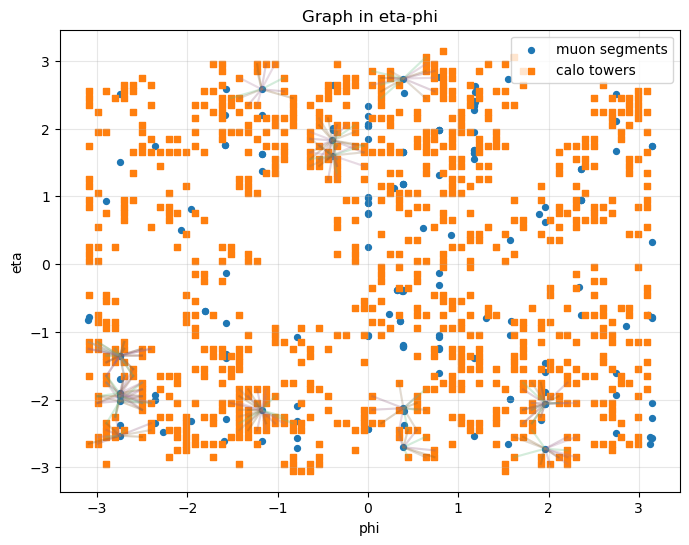

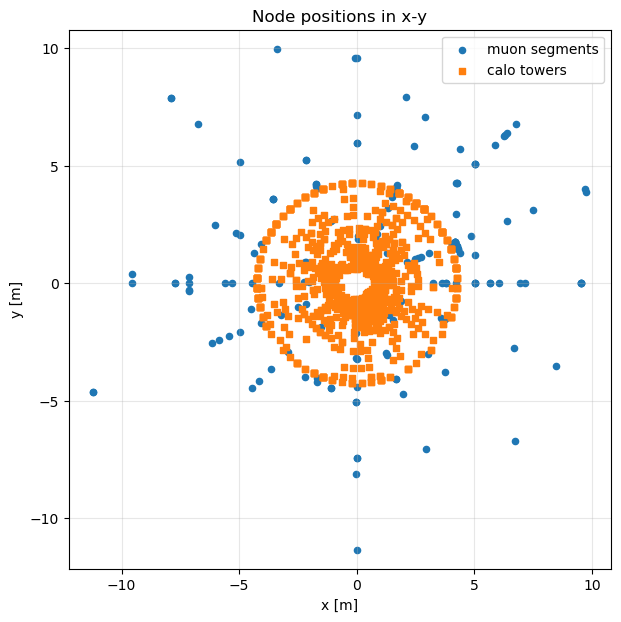

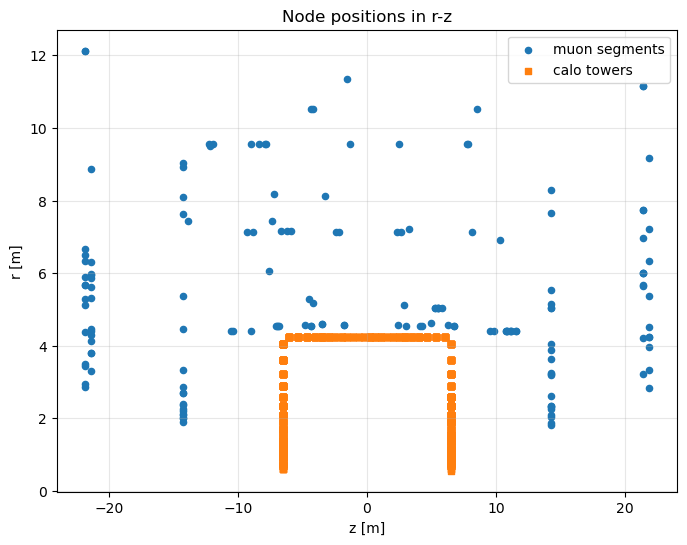

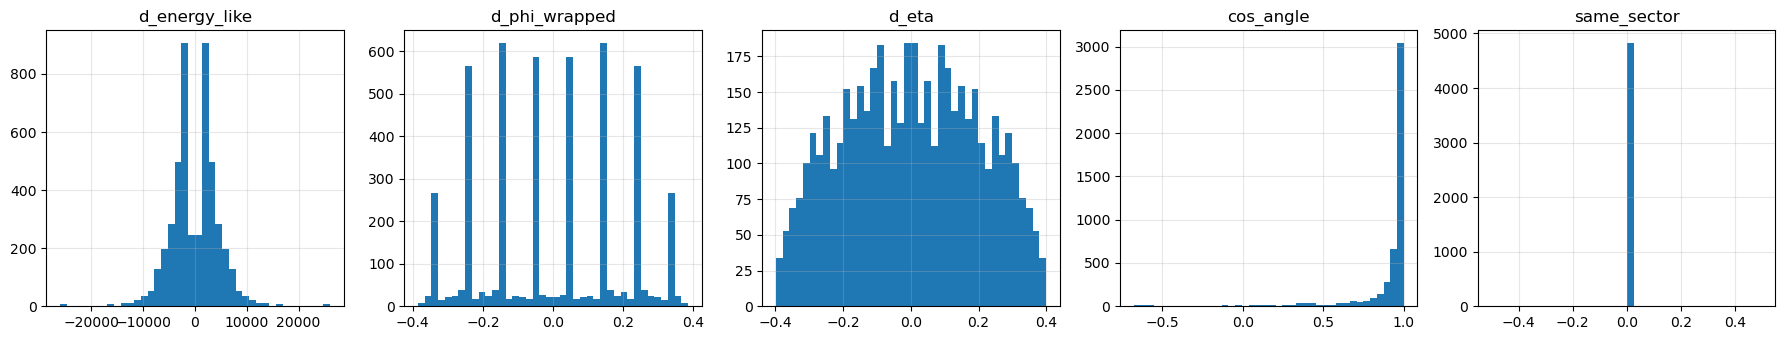

In [17]:
show_event(0)

event index : 1
event_hash  : (5, 2343389991622648)
vertex [m]  : x = 0.0214  y = -0.0211  z = 0.3097
n_nodes     : 1813
n_edges     : 9236
n_mu_nodes  : 160
n_ca_nodes  : 1653
node distance from vertex [m]:
  min = 4.233  mean = 7.388  max = 24.601


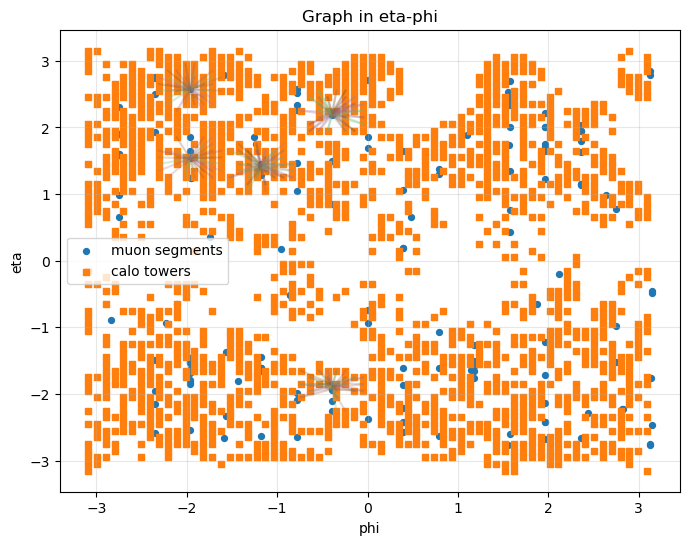

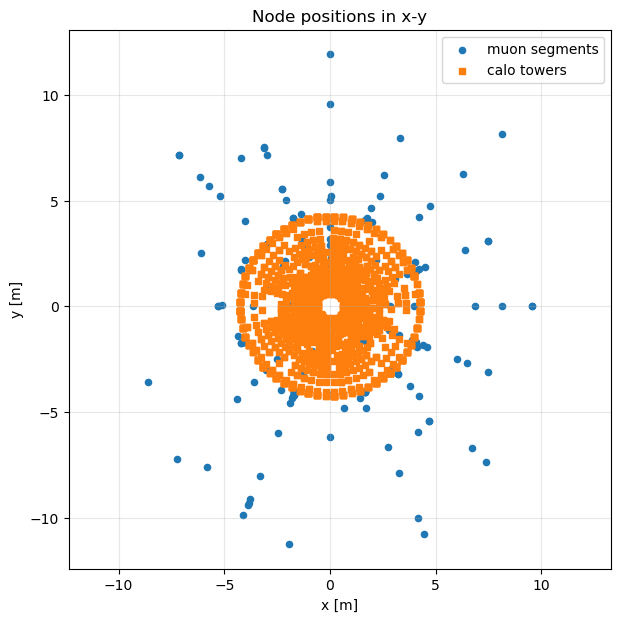

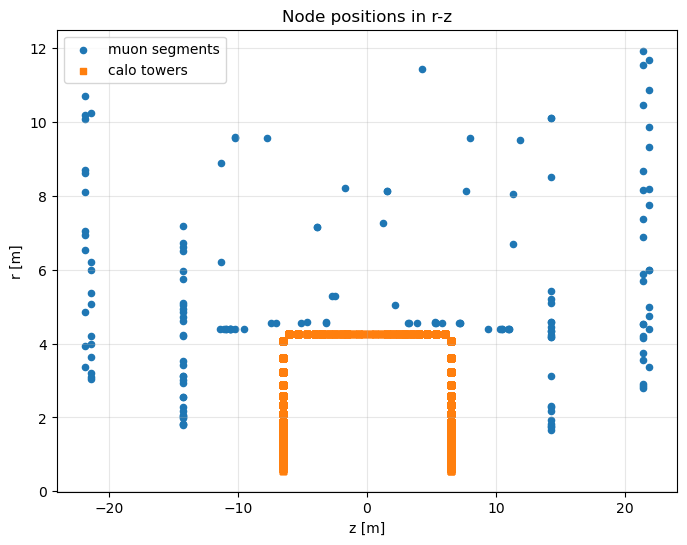

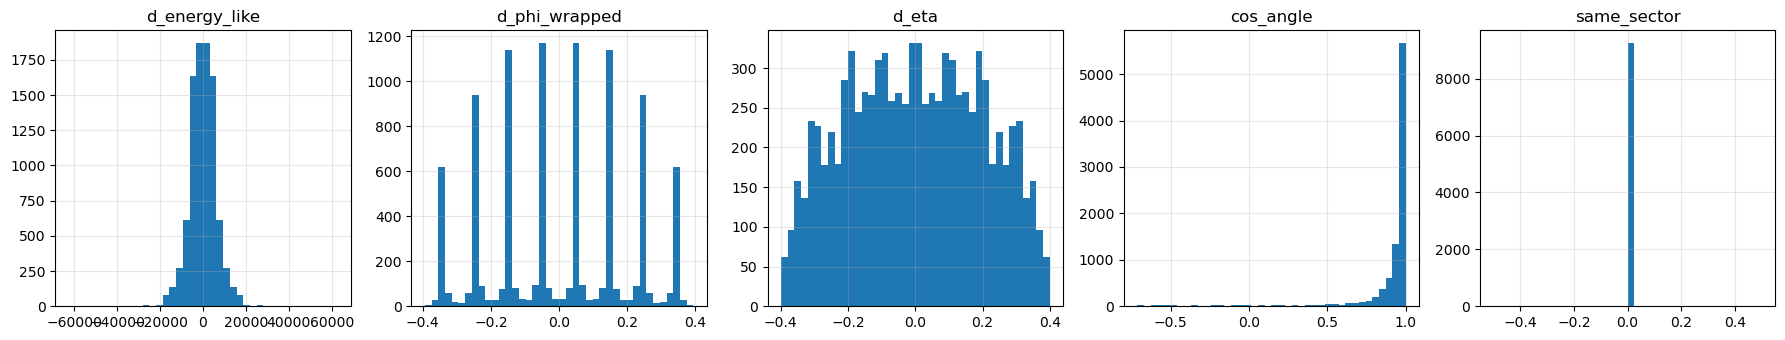

In [18]:
show_event(1)

event index : 2
event_hash  : (12, 2343389991622648)
vertex [m]  : x = -0.0464  y = 0.4244  z = -1.3931
n_nodes     : 1572
n_edges     : 9076
n_mu_nodes  : 204
n_ca_nodes  : 1368
node distance from vertex [m]:
  min = 3.868  mean = 7.726  max = 25.543


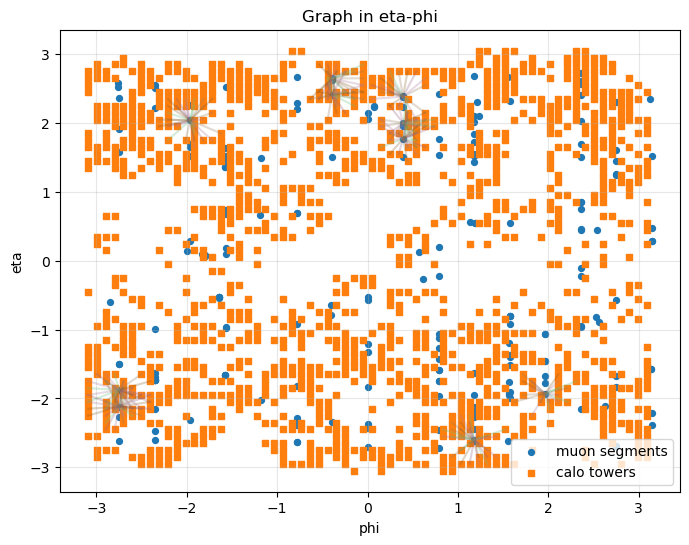

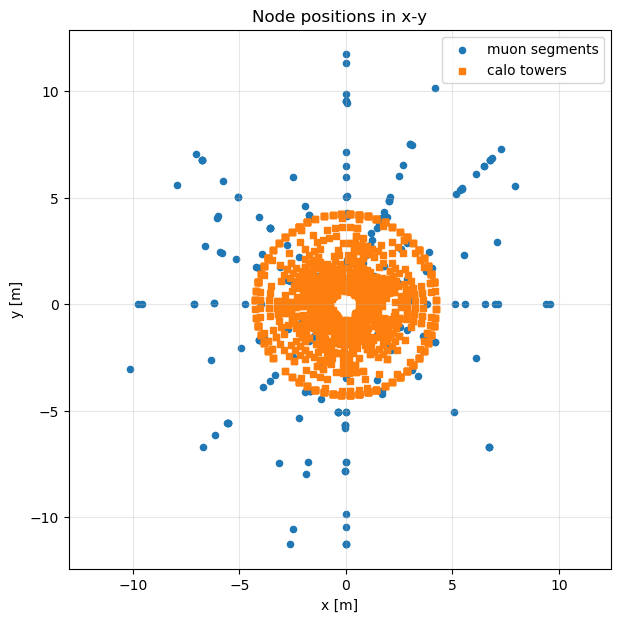

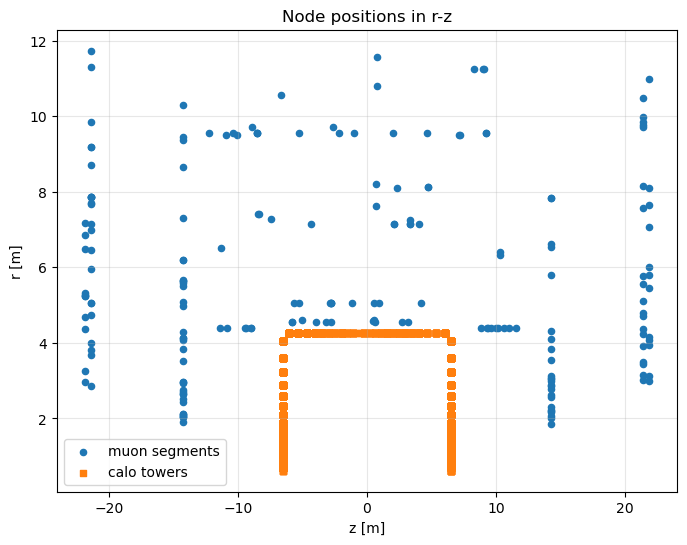

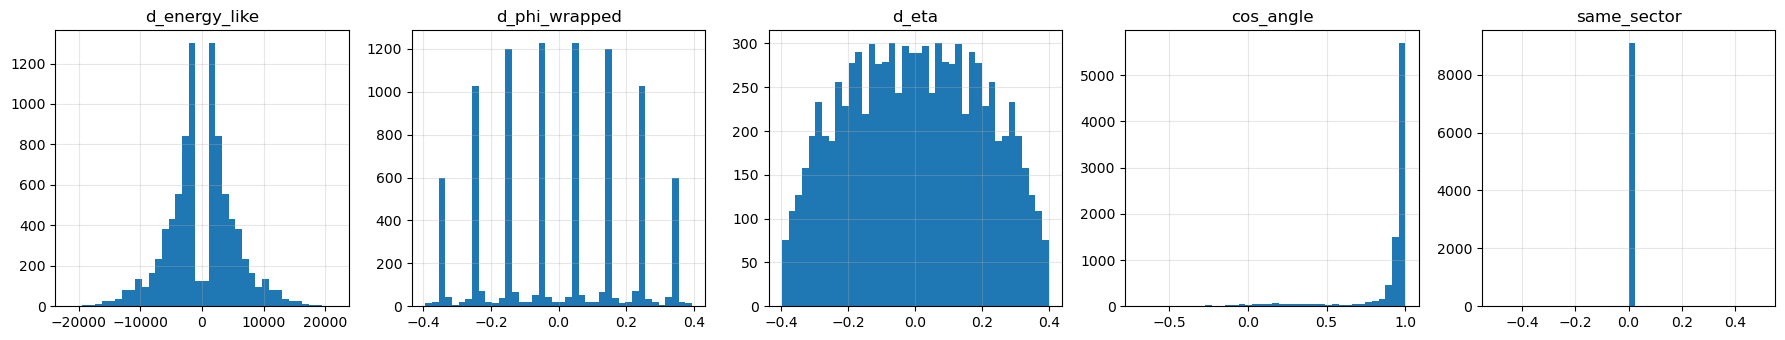

In [19]:
show_event(2)

# Check graph (h5) files

In [32]:
# --- user config ---
H5_DIR = "./data_cylindrical"
H5_GLOB = "displaced_vertex_dataset_part*.h5"   # adapt if needed
MAX_EVENTS_TO_SCAN = None   # e.g. 5000 for faster debug, or None for all
RANDOM_SEED = 123

rng = np.random.default_rng(RANDOM_SEED)

h5_files = sorted(glob.glob(os.path.join(H5_DIR, H5_GLOB)))
print(f"Found {len(h5_files)} files")
for f in h5_files[:5]:
    print("  ", f)
if len(h5_files) > 5:
    print("  ...")

Found 6 files
   ./data_cylindrical/displaced_vertex_dataset_part0001.h5
   ./data_cylindrical/displaced_vertex_dataset_part0002.h5
   ./data_cylindrical/displaced_vertex_dataset_part0003.h5
   ./data_cylindrical/displaced_vertex_dataset_part0004.h5
   ./data_cylindrical/displaced_vertex_dataset_part0005.h5
  ...


In [33]:
def build_event_index(h5_files, max_events=None):
    """
    Returns a list of tuples:
        [(file_path, event_key), ...]
    where event_key is like "0000000" under /events.
    """
    index = []
    for fp in h5_files:
        with h5py.File(fp, "r") as f:
            if "events" not in f:
                continue
            keys = sorted(f["events"].keys())
            for k in keys:
                index.append((fp, k))
                if max_events is not None and len(index) >= max_events:
                    return index
    return index

event_index = build_event_index(h5_files, max_events=MAX_EVENTS_TO_SCAN)
print(f"Indexed {len(event_index)} events")
print("First few:", event_index[:3])

Indexed 52185 events
First few: [('./data_cylindrical/displaced_vertex_dataset_part0001.h5', '0000000'), ('./data_cylindrical/displaced_vertex_dataset_part0001.h5', '0000001'), ('./data_cylindrical/displaced_vertex_dataset_part0001.h5', '0000002')]


In [34]:
def load_event(file_path, event_key):
    """
    Load one event group into a plain dict.
    """
    out = {}
    with h5py.File(file_path, "r") as f:
        g = f["events"][event_key]
        
        # attrs
        out["attrs"] = {k: g.attrs[k] for k in g.attrs.keys()}
        
        # datasets
        for name in g.keys():
            out[name] = g[name][()]
    
    return out


# quick test
sample_event = load_event(*event_index[0])
print("attrs keys:", list(sample_event["attrs"].keys()))
print("dataset keys:", [k for k in sample_event.keys() if k != "attrs"])
for k, v in sample_event.items():
    if k == "attrs":
        continue
    print(f"{k:15s} shape={v.shape} dtype={v.dtype}")

attrs keys: ['dataset_name', 'event_hash', 'n_calo_nodes', 'n_muon_nodes']
dataset keys: ['dir_u', 'edge_attr', 'edge_index', 'energy_like', 'eta', 'muon_bucket', 'muon_xyz_m', 'phi', 'sector', 'tower_min_dr', 'tower_xyz_m', 'x', 'y_vertex']
dir_u           shape=(731, 3) dtype=float32
edge_attr       shape=(3402, 5) dtype=float32
edge_index      shape=(2, 3402) dtype=int64
energy_like     shape=(731,) dtype=float32
eta             shape=(731,) dtype=float32
muon_bucket     shape=(158, 4) dtype=int64
muon_xyz_m      shape=(158, 3) dtype=float32
phi             shape=(731,) dtype=float32
sector          shape=(731,) dtype=int64
tower_min_dr    shape=(573,) dtype=float32
tower_xyz_m     shape=(573, 3) dtype=float32
x               shape=(731, 7) dtype=float32
y_vertex        shape=(3,) dtype=float32


In [35]:
NODE_FEATURE_NAMES = [
    "r_pos",
    "theta_pos",
    "phi_pos",
    "theta_dir",
    "phi_dir",
    "energy_like",
    "nCells_or_DoF",
]

EDGE_FEATURE_NAMES = [
    "d_energy_like",
    "d_phi",
    "d_eta",
    "cos_angle",
    "same_sector",
]

TARGET_NAMES = ["rho_vertex", "phi_vertex", "z_vertex"]

def split_nodes(event):
    """
    Uses stored counts to split x into muon and calo parts.
    """
    x = event["x"]
    n_mu = int(event["attrs"]["n_muon_nodes"])
    n_ca = int(event["attrs"]["n_calo_nodes"])
    mu = x[:n_mu]
    ca = x[n_mu:n_mu+n_ca]
    return mu, ca

def wrap_phi(phi):
    return (phi + np.pi) % (2*np.pi) - np.pi

In [36]:
idx = 0   # change this
ev = load_event(*event_index[idx])

print("File:", event_index[idx][0])
print("Event key:", event_index[idx][1])
print("\nAttributes:")
for k, v in ev["attrs"].items():
    print(f"  {k}: {v}")

print("\nDatasets:")
for k, v in ev.items():
    if k == "attrs":
        continue
    print(f"  {k:15s} shape={v.shape} dtype={v.dtype}")

mu_x, ca_x = split_nodes(ev)
print("\nMuon node features shape:", mu_x.shape)
print("Calo node features shape:", ca_x.shape)
print("Target y_vertex:", ev["y_vertex"])

File: ./data_cylindrical/displaced_vertex_dataset_part0001.h5
Event key: 0000000

Attributes:
  dataset_name: outputs
  event_hash: [            8096 2343364221818872]
  n_calo_nodes: 573
  n_muon_nodes: 158

Datasets:
  dir_u           shape=(731, 3) dtype=float32
  edge_attr       shape=(3402, 5) dtype=float32
  edge_index      shape=(2, 3402) dtype=int64
  energy_like     shape=(731,) dtype=float32
  eta             shape=(731,) dtype=float32
  muon_bucket     shape=(158, 4) dtype=int64
  muon_xyz_m      shape=(158, 3) dtype=float32
  phi             shape=(731,) dtype=float32
  sector          shape=(731,) dtype=int64
  tower_min_dr    shape=(573,) dtype=float32
  tower_xyz_m     shape=(573, 3) dtype=float32
  x               shape=(731, 7) dtype=float32
  y_vertex        shape=(3,) dtype=float32

Muon node features shape: (158, 7)
Calo node features shape: (573, 7)
Target y_vertex: [ 0.03214122 -2.3333848  -0.01774484]


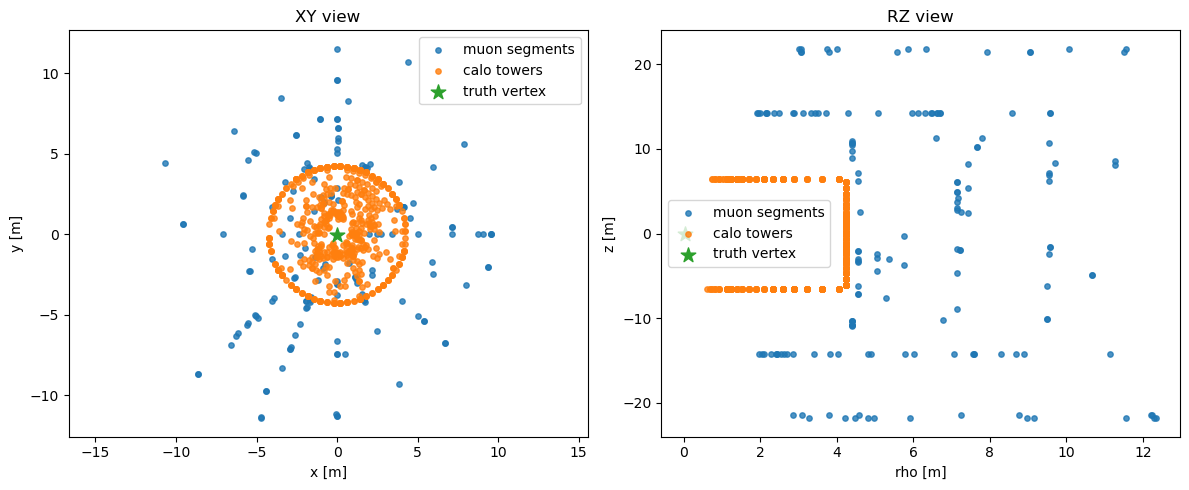

In [37]:
idx = 0   # choose event
ev = load_event(*event_index[idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XY view
ax = axes[0]
if "muon_xyz_m" in ev:
    mu_xyz = ev["muon_xyz_m"]
    ax.scatter(mu_xyz[:, 0], mu_xyz[:, 1], s=15, alpha=0.8, label="muon segments")
if "tower_xyz_m" in ev:
    ca_xyz = ev["tower_xyz_m"]
    ax.scatter(ca_xyz[:, 0], ca_xyz[:, 1], s=15, alpha=0.8, label="calo towers")

rho_v, phi_v, z_v = ev["y_vertex"]
xv = rho_v * np.cos(phi_v)
yv = rho_v * np.sin(phi_v)
ax.scatter([xv], [yv], s=120, marker="*", label="truth vertex")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("XY view")
ax.axis("equal")
ax.legend()

# RZ view
ax = axes[1]
if "muon_xyz_m" in ev:
    mu_r = np.hypot(mu_xyz[:, 0], mu_xyz[:, 1])
    ax.scatter(mu_r, mu_xyz[:, 2], s=15, alpha=0.8, label="muon segments")
if "tower_xyz_m" in ev:
    ca_r = np.hypot(ca_xyz[:, 0], ca_xyz[:, 1])
    ax.scatter(ca_r, ca_xyz[:, 2], s=15, alpha=0.8, label="calo towers")

ax.scatter([rho_v], [z_v], s=120, marker="*", label="truth vertex")

ax.set_xlabel("rho [m]")
ax.set_ylabel("z [m]")
ax.set_title("RZ view")
ax.legend()

plt.tight_layout()
plt.show()

In [40]:
summary = {
    "n_events": 0,
    "n_muon_nodes": [],
    "n_calo_nodes": [],
    "n_edges": [],
    "dataset_names": [],
    "vertex_rho": [],
    "vertex_phi": [],
    "vertex_z": [],
}

for fp, ek in event_index:
    ev = load_event(fp, ek)
    summary["n_events"] += 1
    summary["n_muon_nodes"].append(int(ev["attrs"]["n_muon_nodes"]))
    summary["n_calo_nodes"].append(int(ev["attrs"]["n_calo_nodes"]))
    summary["n_edges"].append(ev["edge_index"].shape[1])
    summary["vertex_rho"].append(float(ev["y_vertex"][0]))
    summary["vertex_phi"].append(float(ev["y_vertex"][1]))
    summary["vertex_z"].append(float(ev["y_vertex"][2]))
    if "dataset_name" in ev["attrs"]:
        summary["dataset_names"].append(str(ev["attrs"]["dataset_name"]))

for k in ["n_muon_nodes", "n_calo_nodes", "n_edges", "vertex_rho", "vertex_z"]:
    arr = np.asarray(summary[k])
    print(
        f"{k:15s} "
        f"min={arr.min():.3f}, max={arr.max():.3f}, mean={arr.mean():.3f}, median={np.median(arr):.3f}"
    )

print("\nDataset counts:")
print(Counter(summary["dataset_names"]).most_common(20))

n_muon_nodes    min=2.000, max=263.000, mean=97.643, median=129.000
n_calo_nodes    min=1.000, max=2583.000, mean=557.779, median=514.000
n_edges         min=2.000, max=17738.000, mean=3165.180, median=2744.000
vertex_rho      min=0.030, max=7.999, mean=0.676, median=0.143
vertex_z        min=-11.989, max=11.993, mean=-0.004, median=-0.003

Dataset counts:
[('outputs', 52185)]


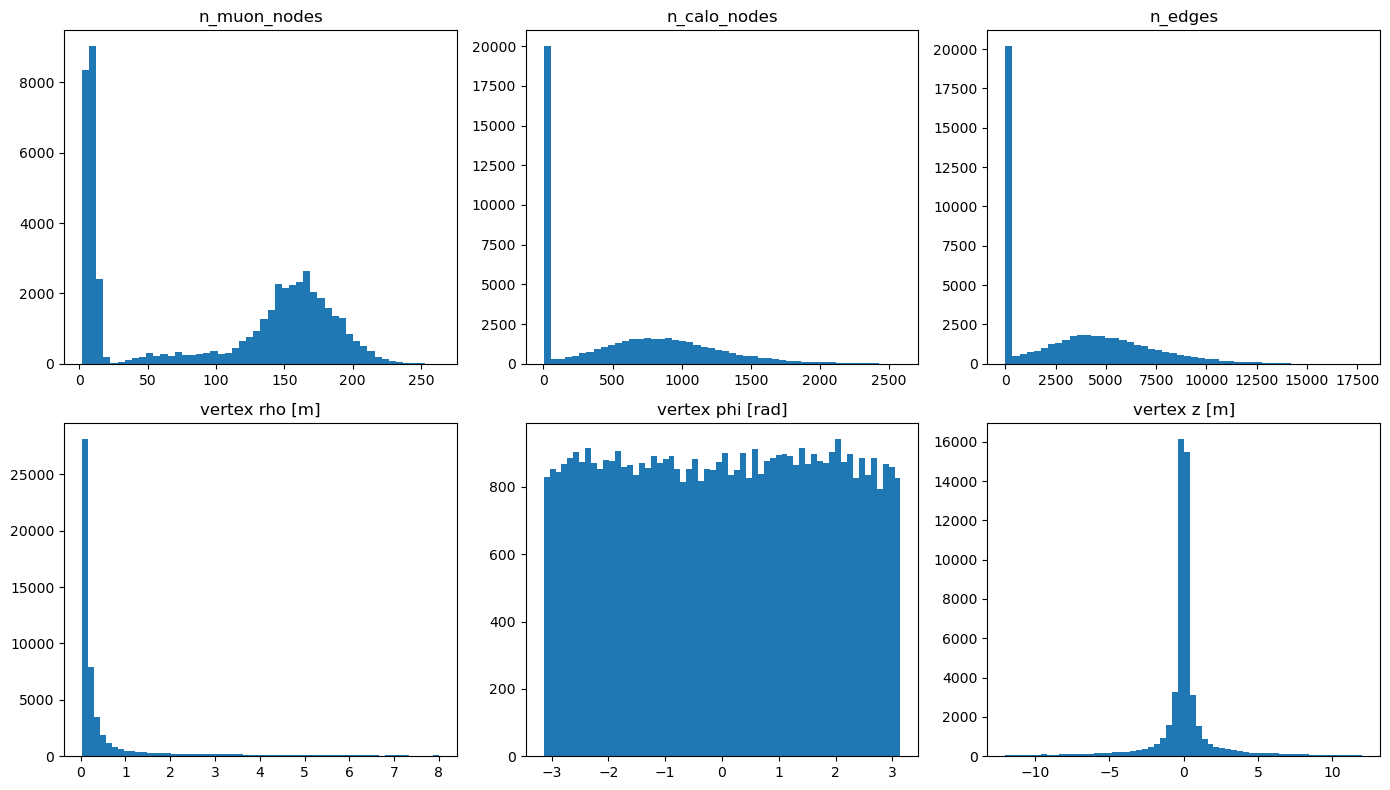

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(summary["n_muon_nodes"], bins=50)
axes[0, 0].set_title("n_muon_nodes")

axes[0, 1].hist(summary["n_calo_nodes"], bins=50)
axes[0, 1].set_title("n_calo_nodes")

axes[0, 2].hist(summary["n_edges"], bins=50)
axes[0, 2].set_title("n_edges")

axes[1, 0].hist(summary["vertex_rho"], bins=60)
axes[1, 0].set_title("vertex rho [m]")

axes[1, 1].hist(summary["vertex_phi"], bins=60)
axes[1, 1].set_title("vertex phi [rad]")

axes[1, 2].hist(summary["vertex_z"], bins=60)
axes[1, 2].set_title("vertex z [m]")

plt.tight_layout()
plt.show()


In [42]:
all_mu_x = []
all_ca_x = []
all_edge_attr = []
all_phi = []
all_eta = []
all_energy_like = []
all_sector = []
all_targets = []

for fp, ek in event_index:
    ev = load_event(fp, ek)
    mu_x, ca_x = split_nodes(ev)

    if len(mu_x) > 0:
        all_mu_x.append(mu_x)
    if len(ca_x) > 0:
        all_ca_x.append(ca_x)

    if ev["edge_attr"].shape[0] > 0:
        all_edge_attr.append(ev["edge_attr"])

    all_phi.append(ev["phi"])
    all_eta.append(ev["eta"])
    all_energy_like.append(ev["energy_like"])
    all_sector.append(ev["sector"])
    all_targets.append(ev["y_vertex"].reshape(1, -1))

all_mu_x = np.concatenate(all_mu_x, axis=0) if len(all_mu_x) else np.zeros((0, 7), dtype=np.float32)
all_ca_x = np.concatenate(all_ca_x, axis=0) if len(all_ca_x) else np.zeros((0, 7), dtype=np.float32)
all_edge_attr = np.concatenate(all_edge_attr, axis=0) if len(all_edge_attr) else np.zeros((0, 5), dtype=np.float32)
all_phi = np.concatenate(all_phi, axis=0)
all_eta = np.concatenate(all_eta, axis=0)
all_energy_like = np.concatenate(all_energy_like, axis=0)
all_sector = np.concatenate(all_sector, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

print("all_mu_x:", all_mu_x.shape)
print("all_ca_x:", all_ca_x.shape)
print("all_edge_attr:", all_edge_attr.shape)
print("all_targets:", all_targets.shape)

all_mu_x: (5095521, 7)
all_ca_x: (29107696, 7)
all_edge_attr: (165174908, 5)
all_targets: (52185, 3)


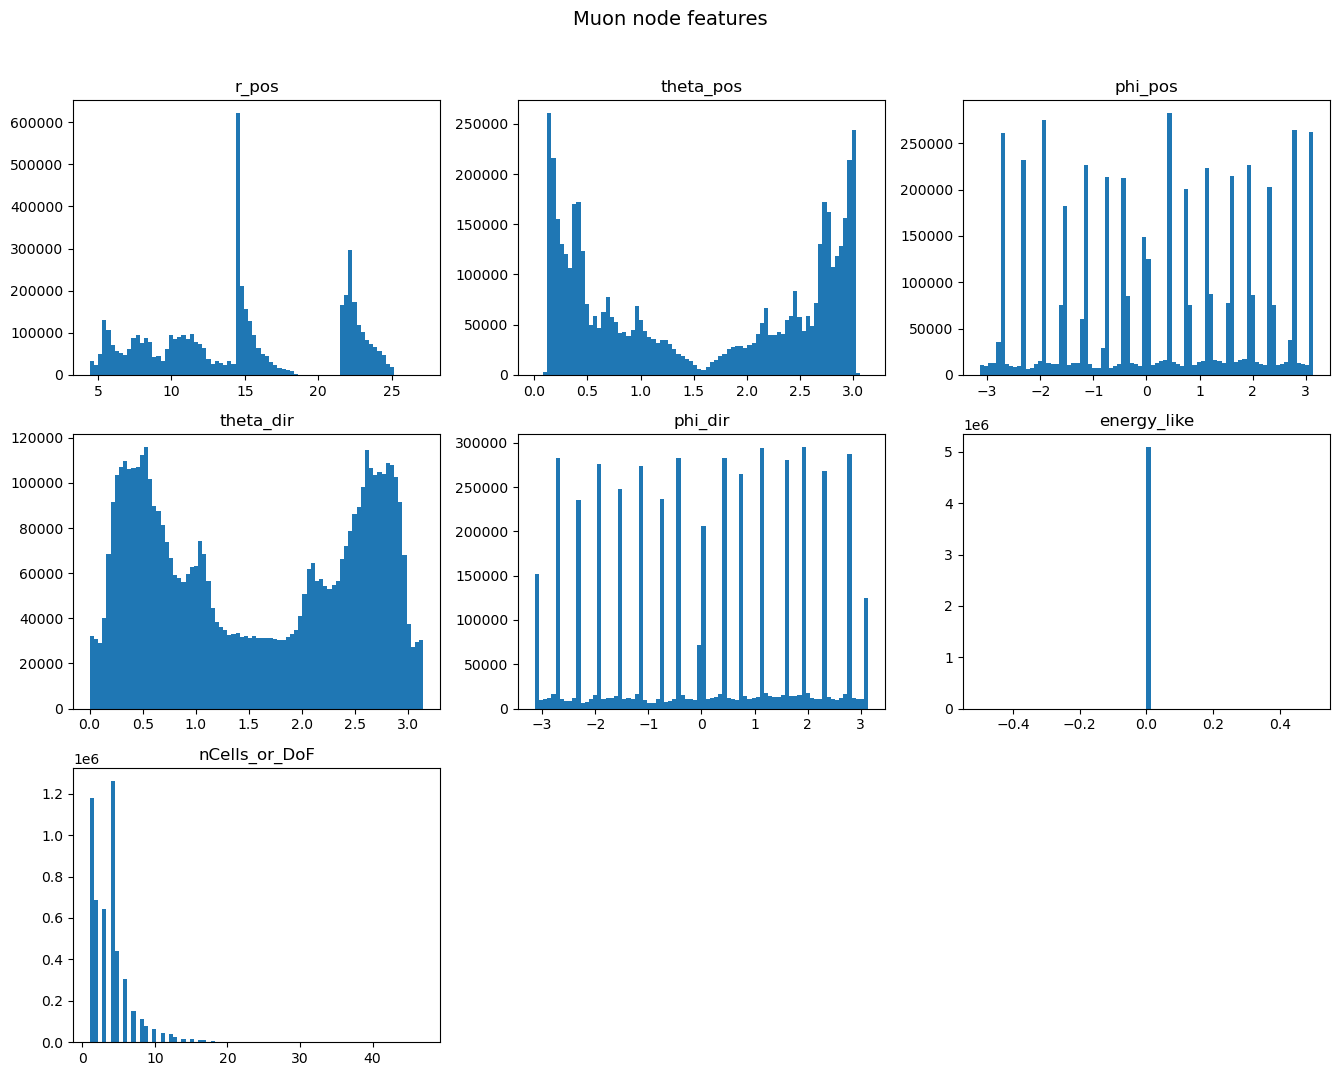

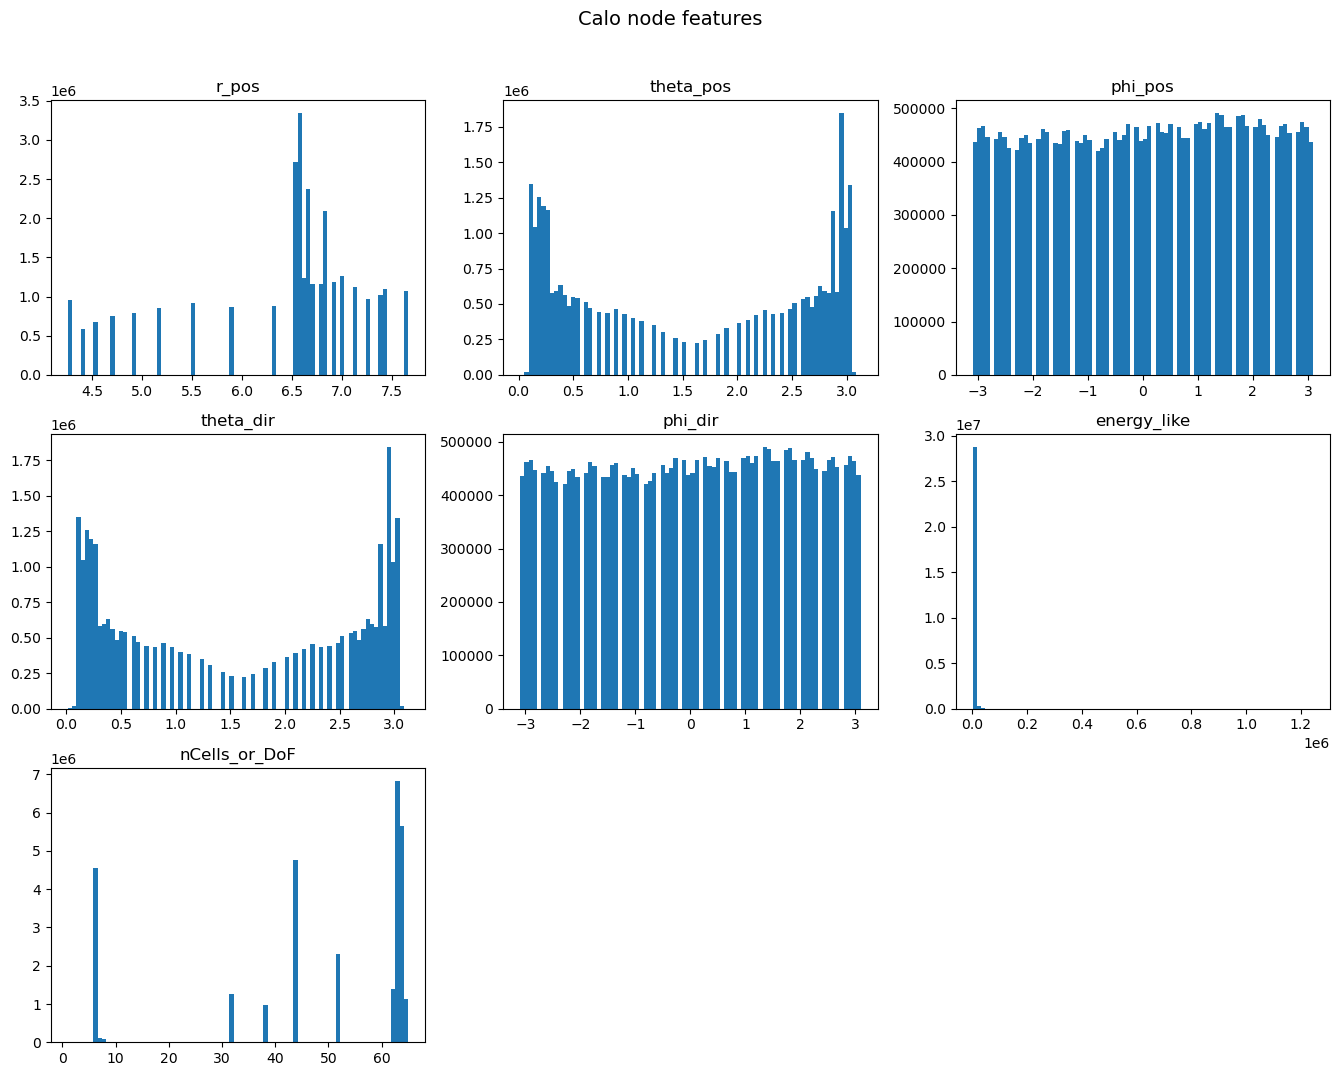

In [43]:
def plot_feature_grid(arr, feature_names, title, bins=80, max_cols=3):
    nfeat = arr.shape[1]
    ncols = min(max_cols, nfeat)
    nrows = int(np.ceil(nfeat / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows))
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for i, name in enumerate(feature_names):
        ax = axes.flat[i]
        vals = arr[:, i]
        ax.hist(vals[np.isfinite(vals)], bins=bins)
        ax.set_title(name)

    for j in range(nfeat, axes.size):
        axes.flat[j].axis("off")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_feature_grid(all_mu_x, NODE_FEATURE_NAMES, "Muon node features")
plot_feature_grid(all_ca_x, NODE_FEATURE_NAMES, "Calo node features")

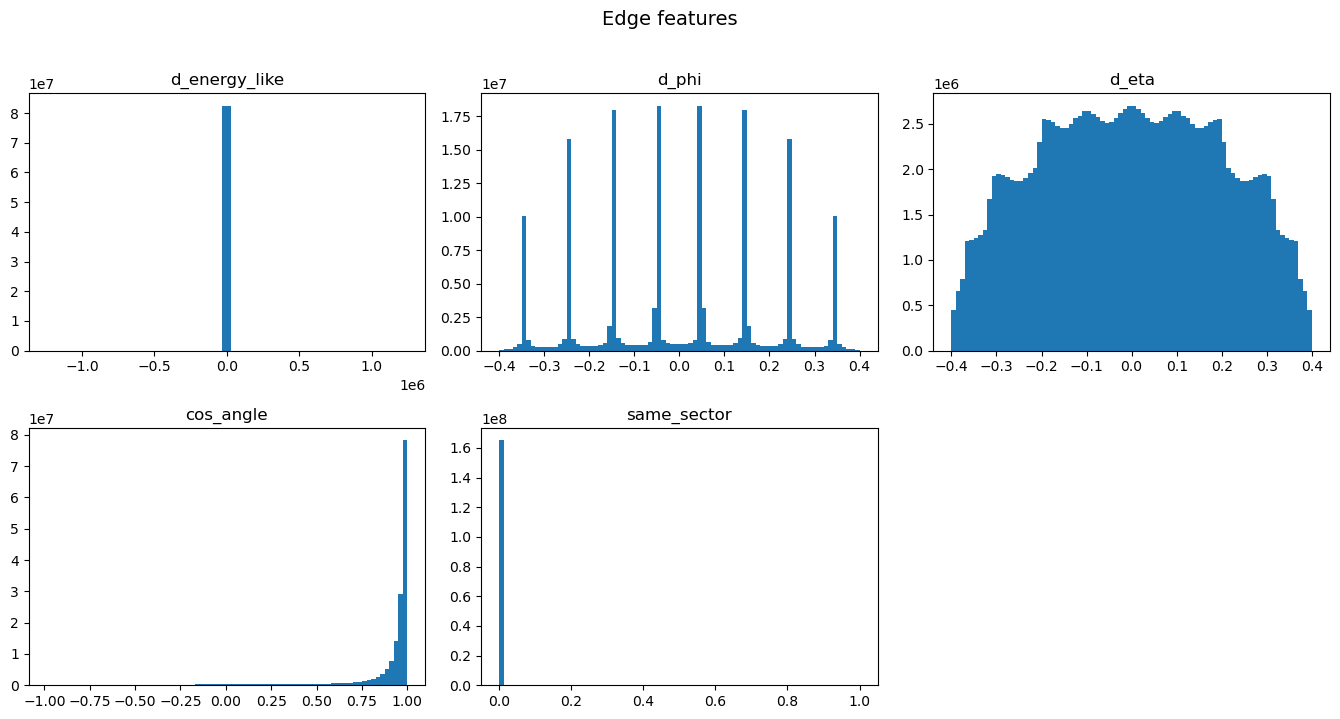

In [44]:
plot_feature_grid(all_edge_attr, EDGE_FEATURE_NAMES, "Edge features")

In [45]:
def describe_columns(arr, names):
    rows = []
    for i, n in enumerate(names):
        x = arr[:, i]
        x = x[np.isfinite(x)]
        rows.append({
            "name": n,
            "mean": float(np.mean(x)),
            "std": float(np.std(x)),
            "min": float(np.min(x)),
            "p01": float(np.percentile(x, 1)),
            "p50": float(np.percentile(x, 50)),
            "p99": float(np.percentile(x, 99)),
            "max": float(np.max(x)),
        })
    return rows

mu_stats = describe_columns(all_mu_x, NODE_FEATURE_NAMES)
ca_stats = describe_columns(all_ca_x, NODE_FEATURE_NAMES)
ed_stats = describe_columns(all_edge_attr, EDGE_FEATURE_NAMES)

print("Muon feature stats")
for row in mu_stats:
    print(row)

print("\nCalo feature stats")
for row in ca_stats:
    print(row)

print("\nEdge feature stats")
for row in ed_stats:
    print(row)

Muon feature stats
{'name': 'r_pos', 'mean': 14.597663879394531, 'std': 5.901322841644287, 'min': 4.430637359619141, 'p01': 4.905385494232178, 'p50': 14.47403621673584, 'p99': 24.558374404907227, 'max': 27.152341842651367}
{'name': 'theta_pos', 'mean': 1.5625016689300537, 'std': 1.0899370908737183, 'min': 0.0034548442345112562, 'p01': 0.13211730122566223, 'p50': 1.4433174133300781, 'p99': 3.0093891620635986, 'max': 3.141192674636841}
{'name': 'phi_pos', 'mean': 0.22044138610363007, 'std': 1.8051778078079224, 'min': -3.1415927410125732, 'p01': -2.799185276031494, 'p50': 0.39269906282424927, 'p99': 3.1415927410125732, 'max': 3.1415927410125732}
{'name': 'theta_dir', 'mean': 1.5564223527908325, 'std': 0.9752736687660217, 'min': 3.343912794662174e-06, 'p01': 0.06272275745868683, 'p50': 1.5058449506759644, 'p99': 3.07560396194458, 'max': 3.1415891647338867}
{'name': 'phi_dir', 'mean': 0.04567490890622139, 'std': 1.818914532661438, 'min': -3.1415927410125732, 'p01': -3.1415927410125732, 'p50

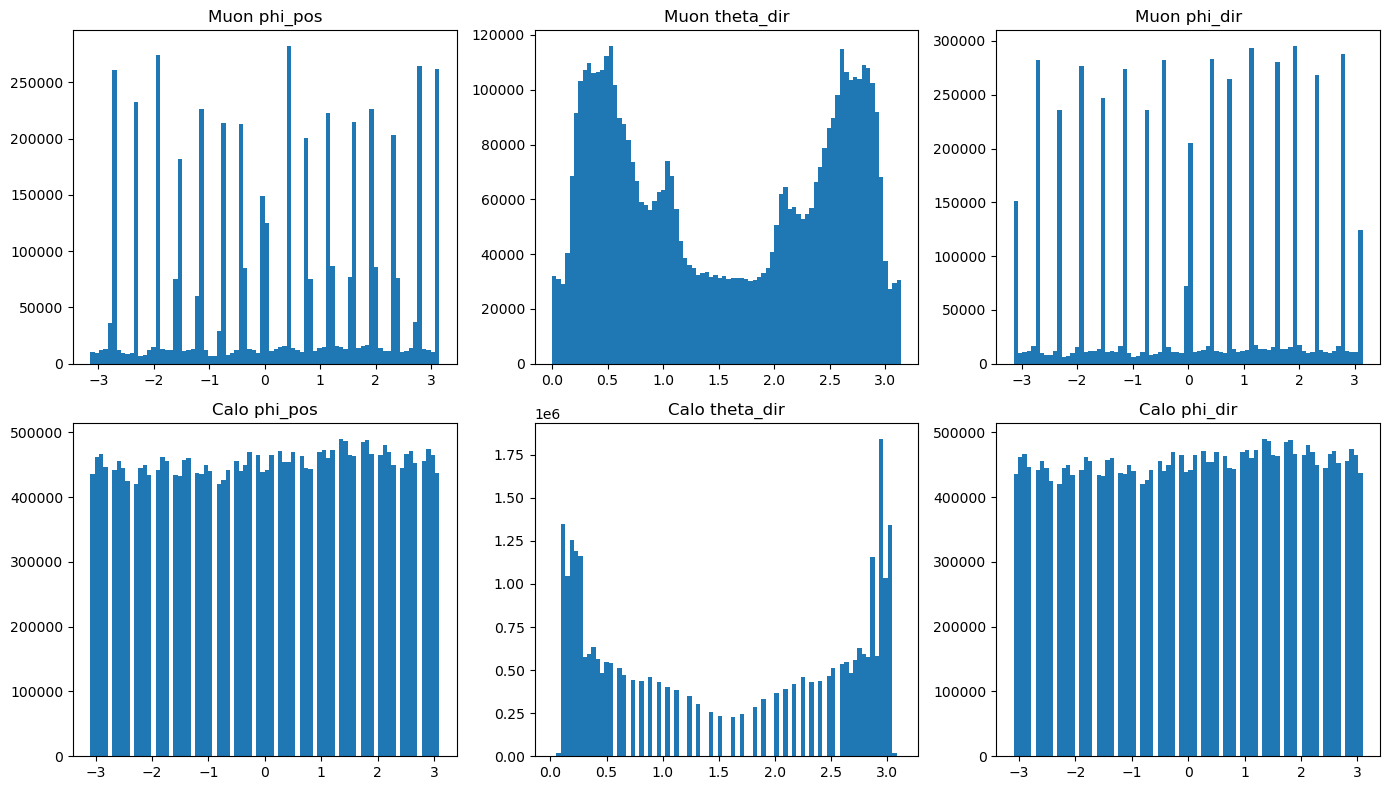

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(all_mu_x[:, 2], bins=80)
axes[0, 0].set_title("Muon phi_pos")

axes[0, 1].hist(all_mu_x[:, 3], bins=80)
axes[0, 1].set_title("Muon theta_dir")

axes[0, 2].hist(all_mu_x[:, 4], bins=80)
axes[0, 2].set_title("Muon phi_dir")

axes[1, 0].hist(all_ca_x[:, 2], bins=80)
axes[1, 0].set_title("Calo phi_pos")

axes[1, 1].hist(all_ca_x[:, 3], bins=80)
axes[1, 1].set_title("Calo theta_dir")

axes[1, 2].hist(all_ca_x[:, 4], bins=80)
axes[1, 2].set_title("Calo phi_dir")

plt.tight_layout()
plt.show()

/media/slowSSD/ddicroce/miniforge3/envs/torch_2p5/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/media/slowSSD/ddicroce/miniforge3/envs/torch_2p5/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


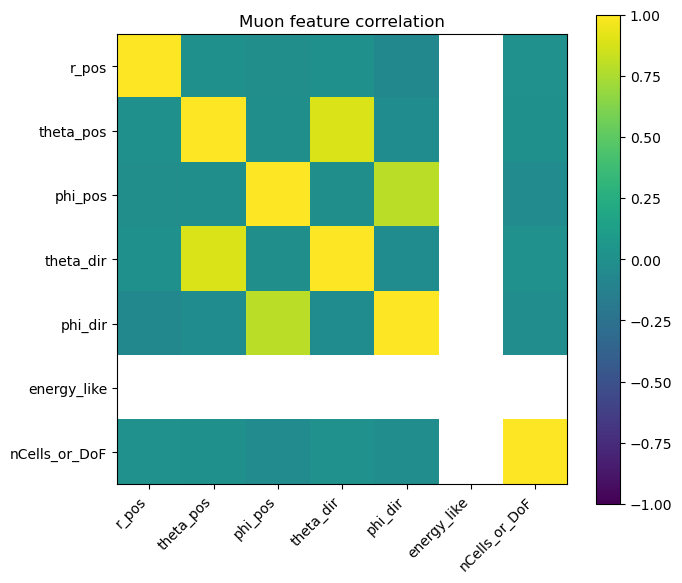

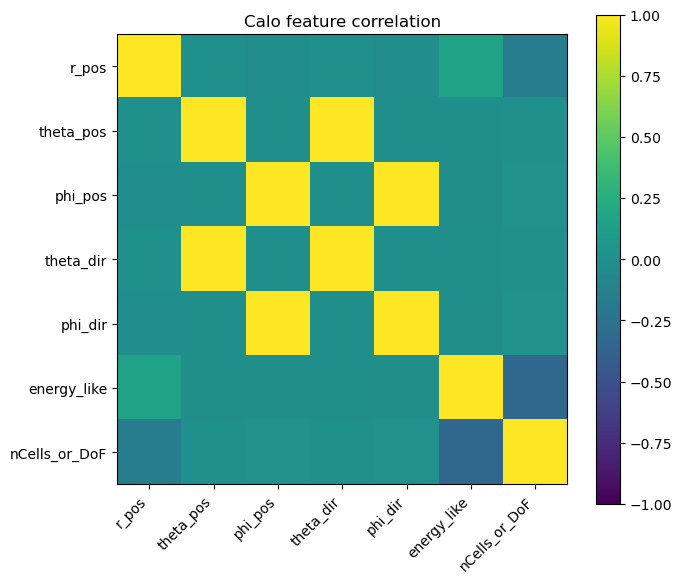

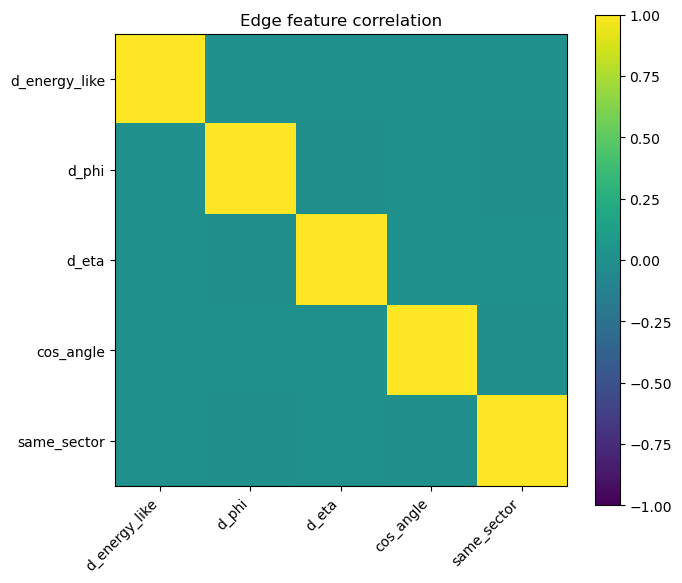

In [47]:
def corrcoef_safe(x):
    x = np.asarray(x, dtype=np.float64)
    mask = np.all(np.isfinite(x), axis=1)
    x = x[mask]
    if len(x) < 2:
        return None
    return np.corrcoef(x, rowvar=False)

mu_corr = corrcoef_safe(all_mu_x)
ca_corr = corrcoef_safe(all_ca_x)
ed_corr = corrcoef_safe(all_edge_attr)

def show_corr(corr, labels, title):
    if corr is None:
        print(f"No valid correlation matrix for {title}")
        return
    plt.figure(figsize=(7, 6))
    plt.imshow(corr, vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()

show_corr(mu_corr, NODE_FEATURE_NAMES, "Muon feature correlation")
show_corr(ca_corr, NODE_FEATURE_NAMES, "Calo feature correlation")
show_corr(ed_corr, EDGE_FEATURE_NAMES, "Edge feature correlation")

In [48]:
def print_outlier_info(arr, names, prefix="", p_low=0.1, p_high=99.9):
    for i, name in enumerate(names):
        x = arr[:, i]
        x = x[np.isfinite(x)]
        lo = np.percentile(x, p_low)
        hi = np.percentile(x, p_high)
        n_lo = int(np.sum(x < lo))
        n_hi = int(np.sum(x > hi))
        print(f"{prefix}{name:15s} lo={lo:10.5f} hi={hi:10.5f}  below={n_lo:8d} above={n_hi:8d}")

print("Muon outlier bands")
print_outlier_info(all_mu_x, NODE_FEATURE_NAMES, prefix="mu/")

print("\nCalo outlier bands")
print_outlier_info(all_ca_x, NODE_FEATURE_NAMES, prefix="ca/")

print("\nEdge outlier bands")
print_outlier_info(all_edge_attr, EDGE_FEATURE_NAMES, prefix="ed/")

Muon outlier bands
mu/r_pos           lo=   4.55859 hi=  25.07732  below=    5094 above=    5094
mu/theta_pos       lo=   0.12335 hi=   3.01819  below=    5095 above=    5095
mu/phi_pos         lo=  -3.10294 hi=   3.14159  below=    5096 above=       0
mu/theta_dir       lo=   0.00689 hi=   3.13459  below=    5096 above=    5096
mu/phi_dir         lo=  -3.14159 hi=   3.14159  below=       0 above=       0
mu/energy_like     lo=   0.00000 hi=   0.00000  below=       0 above=       0
mu/nCells_or_DoF   lo=   1.00000 hi=  19.00000  below=       0 above=    5090

Calo outlier bands
ca/r_pos           lo=   4.25531 hi=   7.66253  below=       0 above=       0
ca/theta_pos       lo=   0.09465 hi=   3.04695  below=   19597 above=   17869
ca/phi_pos         lo=  -3.09251 hi=   3.09251  below=       0 above=       0
ca/theta_dir       lo=   0.09465 hi=   3.04695  below=   19597 above=   17869
ca/phi_dir         lo=  -3.09251 hi=   3.09251  below=       0 above=       0
ca/energy_like     lo=100

In [49]:
def compute_norm_stats(arr, names):
    stats = {}
    for i, name in enumerate(names):
        x = arr[:, i]
        x = x[np.isfinite(x)]

        stats[name] = {
            "mean": float(np.mean(x)),
            "std": float(np.std(x) + 1e-12),
            "median": float(np.median(x)),
            "q01": float(np.percentile(x, 1)),
            "q05": float(np.percentile(x, 5)),
            "q25": float(np.percentile(x, 25)),
            "q50": float(np.percentile(x, 50)),
            "q75": float(np.percentile(x, 75)),
            "q95": float(np.percentile(x, 95)),
            "q99": float(np.percentile(x, 99)),
            "iqr": float(np.percentile(x, 75) - np.percentile(x, 25) + 1e-12),
            "min": float(np.min(x)),
            "max": float(np.max(x)),
        }
    return stats

mu_norm_stats = compute_norm_stats(all_mu_x, NODE_FEATURE_NAMES)
ca_norm_stats = compute_norm_stats(all_ca_x, NODE_FEATURE_NAMES)
ed_norm_stats = compute_norm_stats(all_edge_attr, EDGE_FEATURE_NAMES)
target_norm_stats = compute_norm_stats(all_targets, TARGET_NAMES)

mu_norm_stats["energy_like"], ca_norm_stats["energy_like"], target_norm_stats["rho_vertex"]

({'mean': 0.0,
  'std': 9.999999960041972e-13,
  'median': 0.0,
  'q01': 0.0,
  'q05': 0.0,
  'q25': 0.0,
  'q50': 0.0,
  'q75': 0.0,
  'q95': 0.0,
  'q99': 0.0,
  'iqr': 9.999999960041972e-13,
  'min': 0.0,
  'max': 0.0},
 {'mean': 4004.764892578125,
  'std': 4186.6787109375,
  'median': 2792.808837890625,
  'q01': 1024.948486328125,
  'q05': 1127.2738037109375,
  'q25': 1716.76025390625,
  'q50': 2792.808837890625,
  'q75': 4964.23974609375,
  'q95': 10816.8642578125,
  'q99': 17106.142578125,
  'iqr': 3247.4794921875,
  'min': 1000.0,
  'max': 1243968.125},
 {'mean': 0.6762471199035645,
  'std': 1.3928394317626953,
  'median': 0.14315679669380188,
  'q01': 0.031186839565634727,
  'q05': 0.0358804352581501,
  'q25': 0.06667149811983109,
  'q50': 0.14315679669380188,
  'q75': 0.41034427285194397,
  'q95': 4.07213020324707,
  'q99': 6.994311809539795,
  'iqr': 0.3436727821826935,
  'min': 0.030000856146216393,
  'max': 7.998874187469482})

In [50]:
def print_norm_table(stats, title):
    print(f"\n=== {title} ===")
    for name, s in stats.items():
        print(
            f"{name:15s} "
            f"mean={s['mean']:10.5f} std={s['std']:10.5f} "
            f"median={s['median']:10.5f} iqr={s['iqr']:10.5f} "
            f"p01={s['q01']:10.5f} p99={s['q99']:10.5f}"
        )

print_norm_table(mu_norm_stats, "Muon node stats")
print_norm_table(ca_norm_stats, "Calo node stats")
print_norm_table(ed_norm_stats, "Edge stats")
print_norm_table(target_norm_stats, "Target stats")


=== Muon node stats ===
r_pos           mean=  14.59766 std=   5.90132 median=  14.47404 iqr=  11.79052 p01=   4.90539 p99=  24.55837
theta_pos       mean=   1.56250 std=   1.08994 median=   1.44332 iqr=   2.29541 p01=   0.13212 p99=   3.00939
phi_pos         mean=   0.22044 std=   1.80518 median=   0.39270 iqr=   3.02634 p01=  -2.79919 p99=   3.14159
theta_dir       mean=   1.55642 std=   0.97527 median=   1.50584 iqr=   1.94184 p01=   0.06272 p99=   3.07560
phi_dir         mean=   0.04567 std=   1.81891 median=   0.00000 iqr=   3.14159 p01=  -3.14159 p99=   3.14159
energy_like     mean=   0.00000 std=   0.00000 median=   0.00000 iqr=   0.00000 p01=   0.00000 p99=   0.00000
nCells_or_DoF   mean=   3.76274 std=   2.78402 median=   4.00000 iqr=   3.00000 p01=   1.00000 p99=  14.00000

=== Calo node stats ===
r_pos           mean=   6.42348 std=   0.87537 median=   6.61932 iqr=   0.58833 p01=   4.25531 p99=   7.66253
theta_pos       mean=   1.56636 std=   1.13564 median=   1.52082 iqr= 

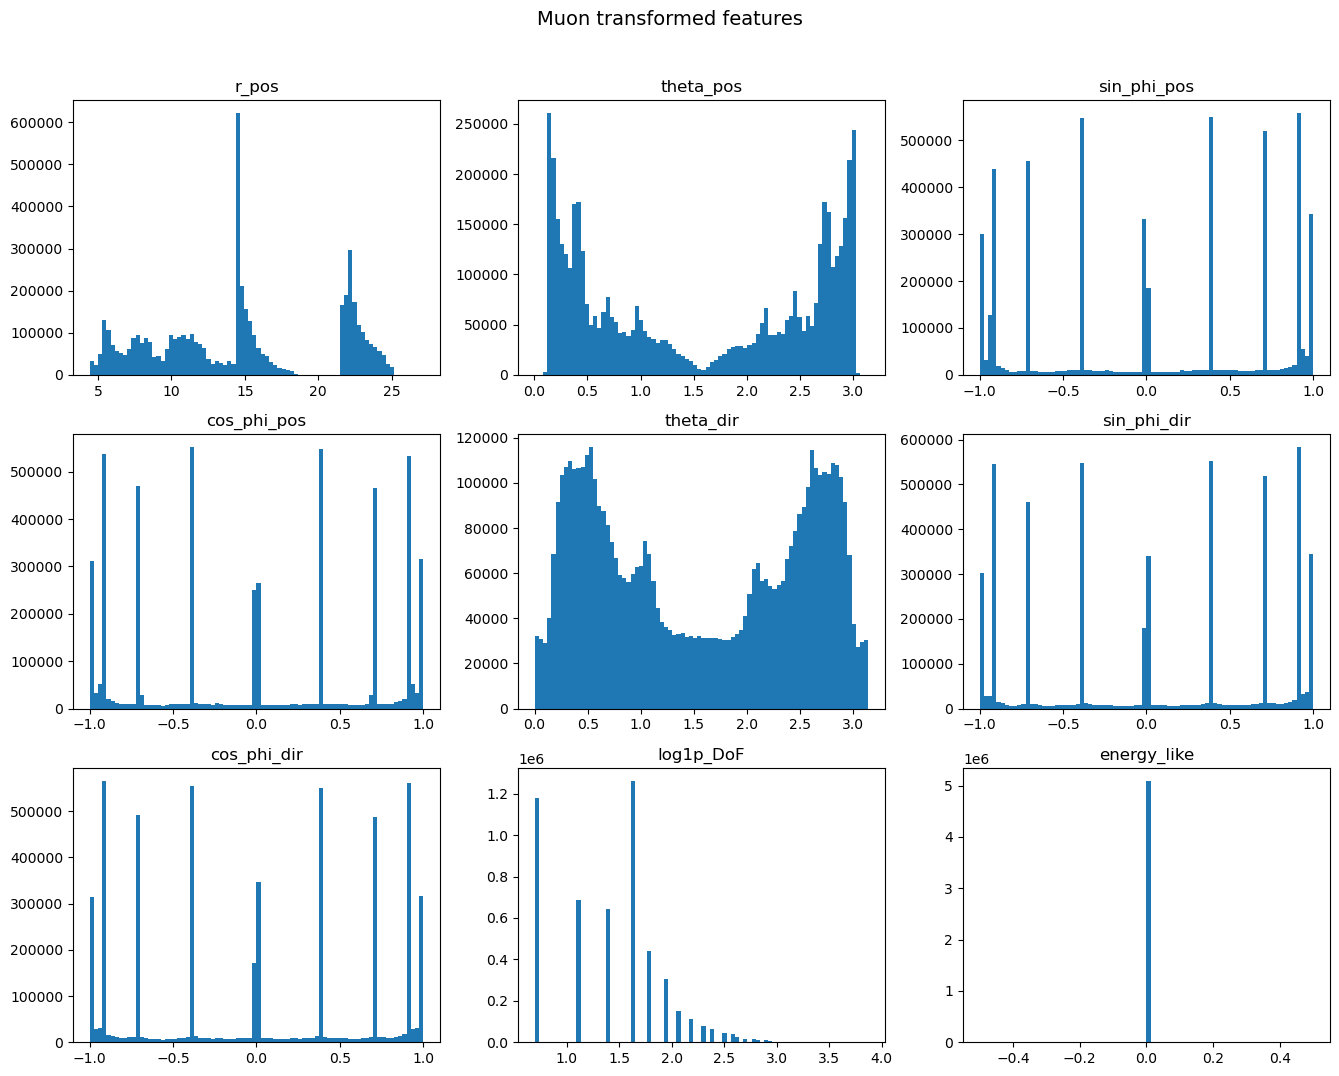

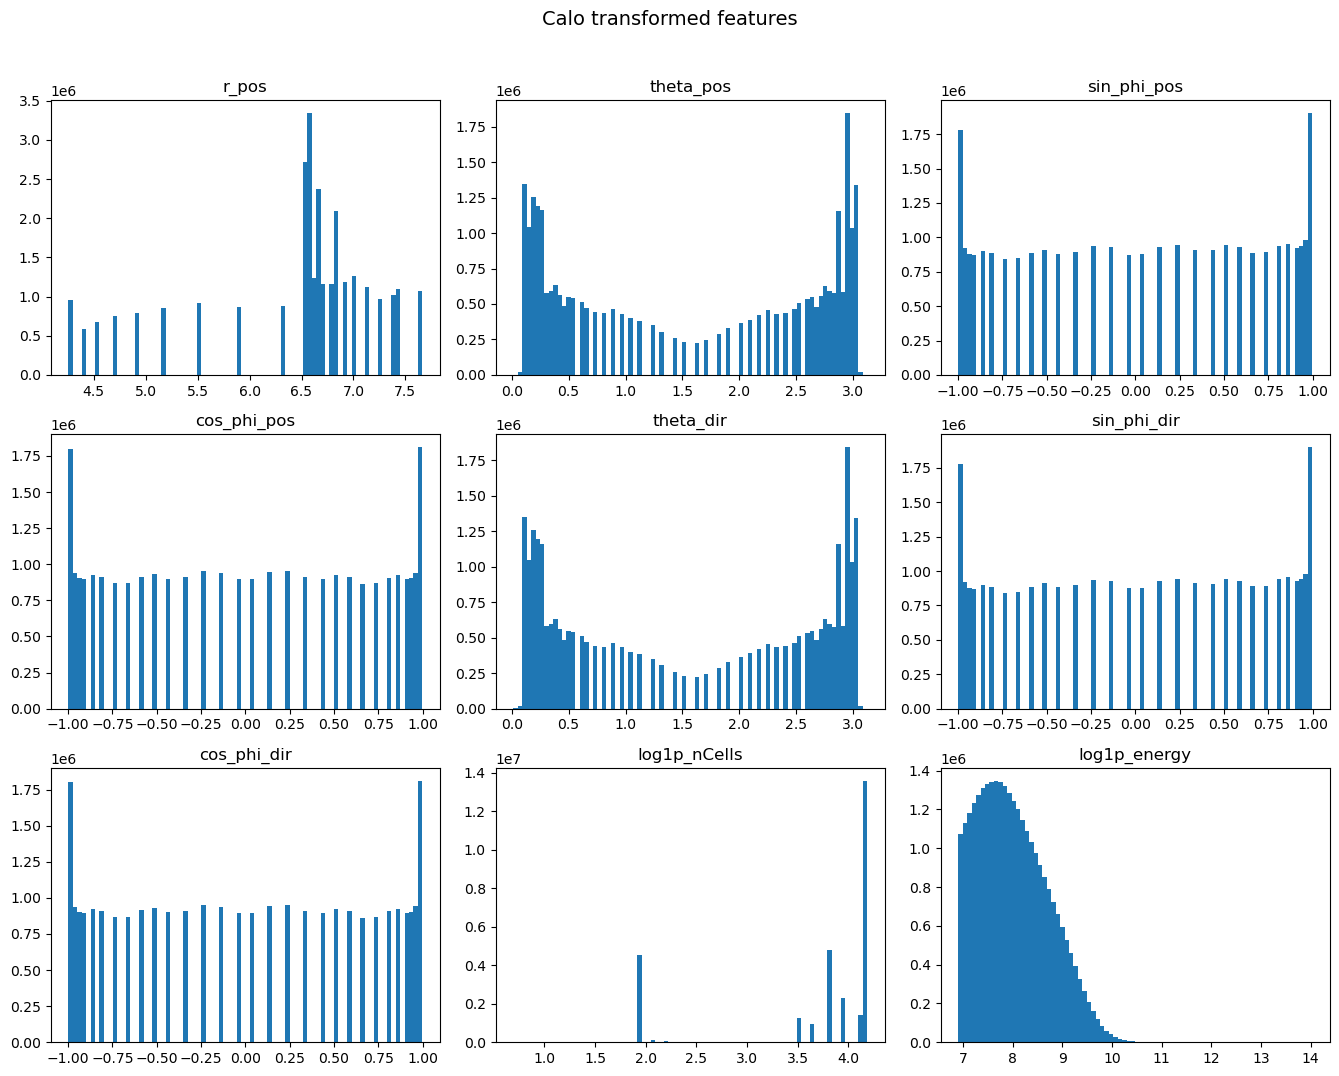

In [51]:
def transform_node_features(x, is_calo):
    """
    Suggested transformed representation for study:
      0 r_pos             -> z-score later
      1 theta_pos         -> z-score later
      2 phi_pos           -> replace with sin/cos
      3 theta_dir         -> z-score later
      4 phi_dir           -> replace with sin/cos
      5 energy_like       -> log1p for calo, keep as-is for muon (muon is zeros)
      6 nCells_or_DoF     -> log1p
    """
    r_pos = x[:, 0:1]
    theta_pos = x[:, 1:2]
    phi_pos = x[:, 2]
    theta_dir = x[:, 3:4]
    phi_dir = x[:, 4]
    energy_like = x[:, 5:6]
    nc = x[:, 6:7]

    out = [
        r_pos,
        theta_pos,
        np.sin(phi_pos)[:, None],
        np.cos(phi_pos)[:, None],
        theta_dir,
        np.sin(phi_dir)[:, None],
        np.cos(phi_dir)[:, None],
        np.log1p(np.maximum(nc, 0.0)),
    ]

    if is_calo:
        out.append(np.log1p(np.maximum(energy_like, 0.0)))
    else:
        out.append(energy_like)

    return np.concatenate(out, axis=1).astype(np.float32)

MU_TRANSFORMED_NAMES = [
    "r_pos",
    "theta_pos",
    "sin_phi_pos",
    "cos_phi_pos",
    "theta_dir",
    "sin_phi_dir",
    "cos_phi_dir",
    "log1p_DoF",
    "energy_like",
]

CA_TRANSFORMED_NAMES = [
    "r_pos",
    "theta_pos",
    "sin_phi_pos",
    "cos_phi_pos",
    "theta_dir",
    "sin_phi_dir",
    "cos_phi_dir",
    "log1p_nCells",
    "log1p_energy",
]

mu_x_t = transform_node_features(all_mu_x, is_calo=False)
ca_x_t = transform_node_features(all_ca_x, is_calo=True)

plot_feature_grid(mu_x_t, MU_TRANSFORMED_NAMES, "Muon transformed features")
plot_feature_grid(ca_x_t, CA_TRANSFORMED_NAMES, "Calo transformed features")

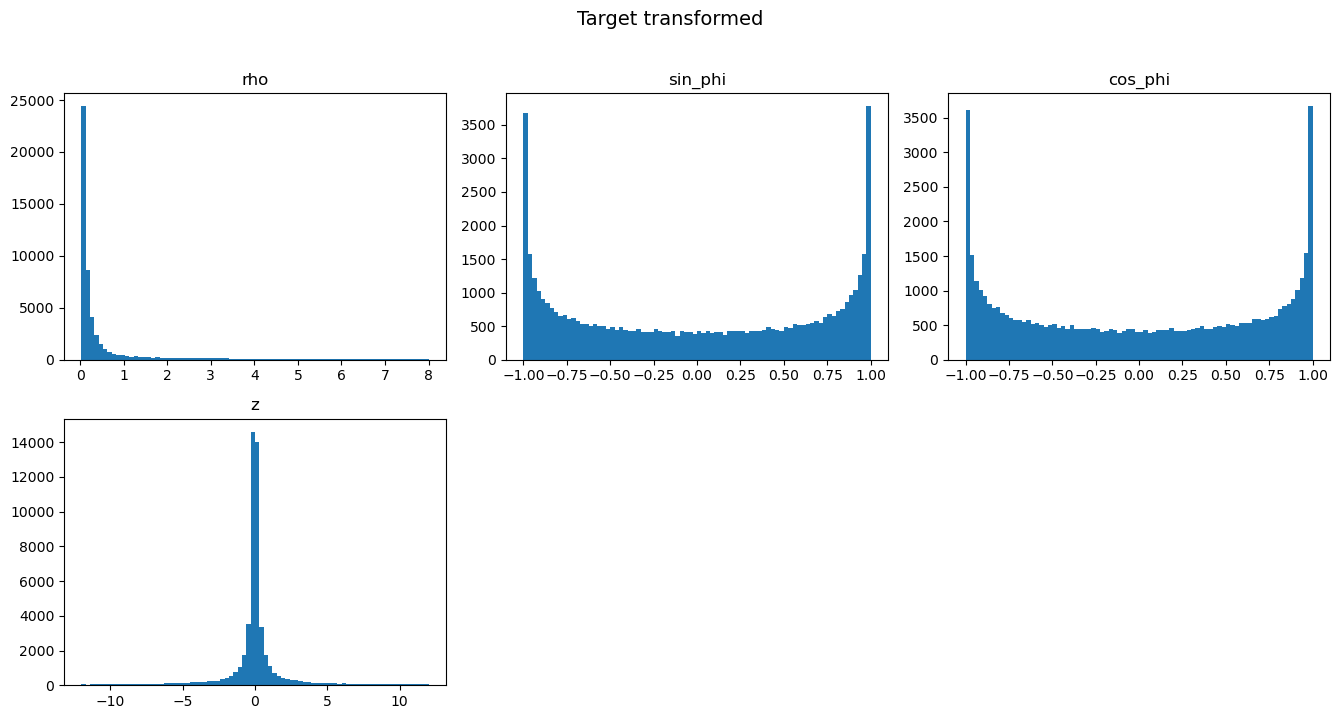


=== Target transformed stats ===
rho             mean=   0.67625 std=   1.39284 median=   0.14316 iqr=   0.34367 p01=   0.03119 p99=   6.99431
sin_phi         mean=   0.00390 std=   0.71020 median=   0.00617 iqr=   1.42952 p01=  -0.99947 p99=   0.99946
cos_phi         mean=   0.00027 std=   0.70399 median=  -0.00174 iqr=   1.39852 p01=  -0.99950 p99=   0.99946
z               mean=  -0.00429 std=   2.39226 median=  -0.00265 iqr=   0.48249 p01=  -9.15700 p99=   9.14409


In [52]:
rho = all_targets[:, 0:1]
phi = all_targets[:, 1]
z = all_targets[:, 2:3]

target_transformed = np.concatenate([
    rho,
    np.sin(phi)[:, None],
    np.cos(phi)[:, None],
    z,
], axis=1)

TARGET_TRANSFORMED_NAMES = ["rho", "sin_phi", "cos_phi", "z"]

plot_feature_grid(target_transformed, TARGET_TRANSFORMED_NAMES, "Target transformed")
print_norm_table(compute_norm_stats(target_transformed, TARGET_TRANSFORMED_NAMES), "Target transformed stats")

In [53]:
def build_standard_scaler_dict(arr, names):
    d = {}
    for i, n in enumerate(names):
        x = arr[:, i]
        x = x[np.isfinite(x)]
        d[n] = {
            "mean": float(np.mean(x)),
            "std": float(np.std(x) + 1e-12),
        }
    return d

def build_robust_scaler_dict(arr, names):
    d = {}
    for i, n in enumerate(names):
        x = arr[:, i]
        x = x[np.isfinite(x)]
        q25 = np.percentile(x, 25)
        q50 = np.percentile(x, 50)
        q75 = np.percentile(x, 75)
        d[n] = {
            "median": float(q50),
            "iqr": float(q75 - q25 + 1e-12),
        }
    return d

mu_std_scaler = build_standard_scaler_dict(mu_x_t, MU_TRANSFORMED_NAMES)
ca_std_scaler = build_standard_scaler_dict(ca_x_t, CA_TRANSFORMED_NAMES)
target_std_scaler = build_standard_scaler_dict(target_transformed, TARGET_TRANSFORMED_NAMES)

mu_robust_scaler = build_robust_scaler_dict(mu_x_t, MU_TRANSFORMED_NAMES)
ca_robust_scaler = build_robust_scaler_dict(ca_x_t, CA_TRANSFORMED_NAMES)
target_robust_scaler = build_robust_scaler_dict(target_transformed, TARGET_TRANSFORMED_NAMES)

print(mu_std_scaler)

{'r_pos': {'mean': 14.597663879394531, 'std': 5.901322841644287}, 'theta_pos': {'mean': 1.5625016689300537, 'std': 1.0899370908737183}, 'sin_phi_pos': {'mean': 0.03369617834687233, 'std': 0.7079674601554871}, 'cos_phi_pos': {'mean': -0.0005722930654883385, 'std': 0.7054402232170105}, 'theta_dir': {'mean': 1.5564223527908325, 'std': 0.9752736687660217}, 'sin_phi_dir': {'mean': 0.031810831278562546, 'std': 0.7079339623451233}, 'cos_phi_dir': {'mean': -0.0009599736658856273, 'std': 0.7055613398551941}, 'log1p_DoF': {'mean': 1.4186809062957764, 'std': 0.5256707072257996}, 'energy_like': {'mean': 0.0, 'std': 9.999999960041972e-13}}


In [54]:
import json

norm_payload = {
    "mu_standard": mu_std_scaler,
    "ca_standard": ca_std_scaler,
    "target_standard": target_std_scaler,
    "mu_robust": mu_robust_scaler,
    "ca_robust": ca_robust_scaler,
    "target_robust": target_robust_scaler,
}

out_json = os.path.join(H5_DIR, "normalization_stats.json")
with open(out_json, "w") as f:
    json.dump(norm_payload, f, indent=2)

print("Wrote:", out_json)

Wrote: ./data_cylindrical/normalization_stats.json


In [55]:
def standardize(x, stats, names):
    x = x.copy().astype(np.float32)
    for i, n in enumerate(names):
        x[:, i] = (x[:, i] - stats[n]["mean"]) / stats[n]["std"]
    return x

def robust_standardize(x, stats, names):
    x = x.copy().astype(np.float32)
    for i, n in enumerate(names):
        x[:, i] = (x[:, i] - stats[n]["median"]) / stats[n]["iqr"]
    return x

In [56]:
idx = 0
ev = load_event(*event_index[idx])
mu_x, ca_x = split_nodes(ev)

mu_x_t_ev = transform_node_features(mu_x, is_calo=False)
ca_x_t_ev = transform_node_features(ca_x, is_calo=True)

mu_x_norm = robust_standardize(mu_x_t_ev, mu_robust_scaler, MU_TRANSFORMED_NAMES)
ca_x_norm = robust_standardize(ca_x_t_ev, ca_robust_scaler, CA_TRANSFORMED_NAMES)

rho_v, phi_v, z_v = ev["y_vertex"]
target_ev_t = np.array([[rho_v, np.sin(phi_v), np.cos(phi_v), z_v]], dtype=np.float32)
target_ev_norm = robust_standardize(target_ev_t, target_robust_scaler, TARGET_TRANSFORMED_NAMES)

print("mu_x_norm shape:", mu_x_norm.shape)
print("ca_x_norm shape:", ca_x_norm.shape)
print("target_ev_norm:", target_ev_norm)

mu_x_norm shape: (158, 9)
ca_x_norm shape: (573, 9)
target_ev_norm: [[-0.32302696 -0.51011604 -0.49270514 -0.0312847 ]]
